# 알고리즘 기말 프로젝트 — Score Function Design

- **제출일**: `2026.06.21`
- **파일명**: `김나연_20250786_pesticide.ipynb`

## 학번 / 이름

- **학번**: `20250786`
- **이름**: `김나연`
- **score에 대한 간략한 설명**:  `pesticide`-likeness를 계산하는 score
  - Pesticide-likeness 스코어링 시스템 개요
  - 화합물의 물리화학적 속성과 고유 구조 패턴(골격/잔기)을 기반으로 임의의 화합물이 실제 농약의 물성 및 구조적 특징을 얼마나 닮았는지 정량화하는 스코어링 시스템 구현

## 채점 기준 (100점)

| 영역 | 배점 | 만점 기준 |
|---|---|---|
| **(1) Negative 데이터 준비** | 20 | "구조 유사도"를 통해 negative 집합을 찾아낸 기준? (유사도 측정 방법 & Structural similarity 기준 설정) |
| **(2) Score 함수 설계** | 20 | **(a) 분자 속성 범위 (전체 데이터에서 property 범위 계산 방식)** + **(b) alert 구조 패턴(scaffold 및 부분 구조의 smarts 패턴)** 두 요소 모두 포함. score에 대한 설명은 markdown에 기재. |
| **(3) Score 평가 — goodness** | 20 | positive vs negative 점수 분포 비교 (히스토그램/ROC/AUC 등 score 성능의 근거가 되는 시각화 자료 제시) |
| **(4) 설명** | 10 | 각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기) |


### 가산점 (선택)

| 가산 | 점수 | 조건 |
|---|---|---|
| **(A) 다른 화학 제품군 score** | +10 | pesticide 외 1종 이상(cosmetic / food additive / fragrance / surfactant / dye 등)의 PubChem classification 데이터로 별도 score 함수 설계 + 평가 |
| **(B) Score 기반 구조 생성** | +10 | 본인 score 를 reward 로 사용해 score가 개선된 새로운 구조 생성. |
| **(C) 계산 자원과 계산 시간** | +10 | mpi를 이용해서 대량의 자원으로 계산 시간을 대폭 줄이거나, local 환경에서 합리적으로 계산이 진행될 수 있도록 문제를 효율적으로 압축시킨 방법 적용 (mpi script와 계산 결과에 대한 log 필요) |

### 제출 결과물 (결과를 재현하기 위해 필요한 파일들)
1. ipynb (mpi를 사용했다면, mpi4py script)
2. data files (pesticide, cosmetics, food additives, drug, ..., format: csv)
3. negative list file (format: csv)
4. score 평가 시각화 자료 (mpi에서 실행해서 얻은 plot은 notebook markdown에 삽입)

---
# Task 1. Negative 데이터 준비 (25점)
**문제**: 양성(positive) 분자와 "구조적으로 다른" 분자 집합을 어떻게 만들 것인가?
Score 함수의 평가는 **양성과 음성을 얼마나 잘 구분하는가** 로 측정한다. 그러려면 먼저 음성 집합을 정의해야 한다.

**📝 본인 선택과 이유 (직접 작성):**

- **선택한 기준**:
  1. **음성 대조군용 ZINC 데이터 로드 및 표준화**: ZINC 데이터베이스로부터 분자들을 불러와 표준화하고 중복을 제거한 후, 양성 농약군에 존재하는 분자들을 제거한다.
  2. **구조 유사도 필터링 (Structural Similarity Filter)**: 2048-bit Morgan Fingerprint (radius=2)와 Tanimoto Coefficient를 사용해 양성군과의 최대 구조 유사도를 계산한다. 양성군 자가 유사도 분포와 ZINC 후보군 유사도 분포의 교차점(Crossing Point)을 동적으로 계산하여 최적의 Cutoff를 자동 결정한다.
  3. **음성 데이터 선별 개수 (N=양성 대비 1:1 균형 및 무작위 추출)**: Cutoff 이하를 만족하는 ZINC 후보 분자들을 대상으로, 양성 데이터 크기(N=3,085) 한도 내에서 무작위 추출(Random Sampling)을 수행한다.

- **이유**:
  1. **ZINC 데이터 사용 및 표준화 이유**: 양성군(농약)과 명확히 구분되는 대조군을 형성하기 위해 ZINC 화학 라이브러리 데이터를 사용하고, 표준화 및 중복 제거를 통해 분석의 정밀도를 높이기 위함이다.
  2. **구조 유사도 필터링 및 동적 Cutoff 적용 이유**: 분석가가 고정된 임계치를 임의로 정하는 대신, 양성군 내부의 자가 유사도 분포와 ZINC 후보군의 유사도 분포가 만나는 교차점을 계산하여 자동으로 설정한다. 이를 통해 고정된 수치가 아닌, 실제 데이터의 유사도 분포 특성을 반영한 객관적인 기준을 유연하게 도출하기 위함이다.
  3. **전체 파일 대신 일부 파일 무작위 샘플링 및 균형 크기 추출 이유**:
    - ZINC의 68개 전체 파일을 다 돌리면 연산 시간이 48시간 이상 소요되어 완료되지 않는 병목이 발생하며, 최종 선별할 데이터(3,085개)보다 필요 이상으로 많은 양의 데이터가 수집되어 비효율적이다.
    - 이에 따라 필요한 개수의 약 100배 크기의 충분한 후보 풀이 모일 때까지만 일부 파일을 무작위로 골라 스캔하여 연산 낭비를 차단했다.
    - 이후 수집된 후보 풀에서 최종적으로 양성 데이터 개수에 맞게 무작위 추출을 수행하여 학습의 균형을 맞춘다.

In [191]:
# 라이브러리 임포트 및 경고 메시지 차단
import warnings
warnings.filterwarnings('ignore')

import io
import re
import time
import base64
import math
import glob
import random
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from pathlib import Path
from scipy.stats import skew, gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, Descriptors, Crippen, MACCSkeys, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect, GetTopologicalTorsionFingerprint
from rdkit.DataStructs import BulkTanimotoSimilarity

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc, average_precision_score, 
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, matthews_corrcoef, precision_recall_curve,
    confusion_matrix
)
from IPython.display import display, HTML, Markdown, Image as IPImage

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')


In [192]:
# 1. 양성(Positive) 농약 데이터 로드 및 RDKit Canonical SMILES 표준화 처리
pos_df = pd.read_csv('PubChem_Agrochemical.csv')
pos_df = pos_df.dropna(subset=['smiles']).copy()
pos_df['mol'] = [Chem.MolFromSmiles(s) for s in pos_df['smiles']]
pos_df = pos_df[pos_df['mol'].notna()].copy()
pos_df['standardized_smi'] = [Chem.MolToSmiles(m) for m in pos_df['mol']]
pos_df = pos_df.drop_duplicates(subset='standardized_smi').reset_index(drop=True)
pos_df['smiles'] = pos_df['standardized_smi']
pos_smi_set = set(pos_df['standardized_smi'])

# Fingerprint Generator (Morgan FP, 반경 2, 2048 비트) 생성
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
ref_fps = [fp_gen.GetFingerprint(m) for m in pos_df['mol']]

print(f"양성 데이터(Agrochemical) 수량: {len(pos_df)}개")

양성 데이터(Agrochemical) 수량: 3085개


### 유사도 구간: 0.0-0.1 (샘플 4개쌍)


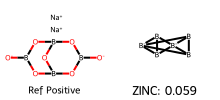
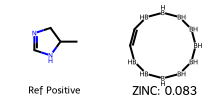
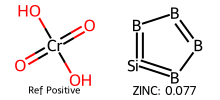
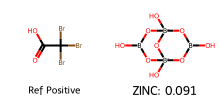

### 유사도 구간: 0.1-0.2 (샘플 4개쌍)


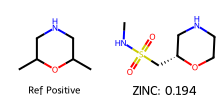
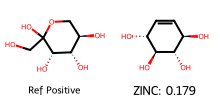
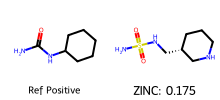
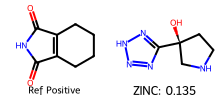

### 유사도 구간: 0.2-0.3 (샘플 4개쌍)


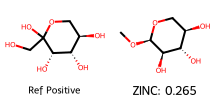
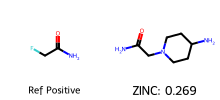
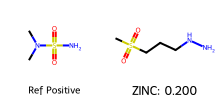
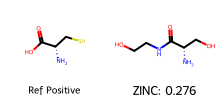

### 유사도 구간: 0.3-0.4 (샘플 4개쌍)


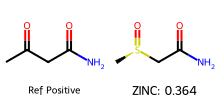
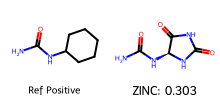
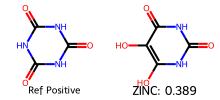
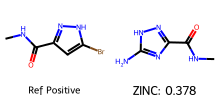

### 유사도 구간: 0.4-0.5 (샘플 4개쌍)


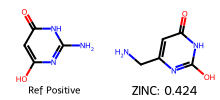
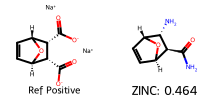
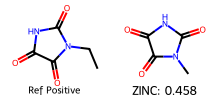
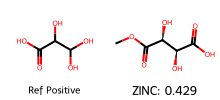

### 유사도 구간: 0.5-0.6 (샘플 4개쌍)


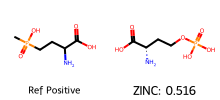
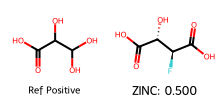
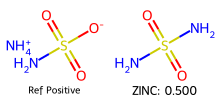
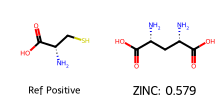

### 유사도 구간: 0.6-0.7 (샘플 4개쌍)


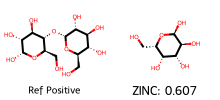
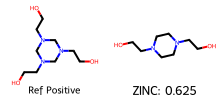
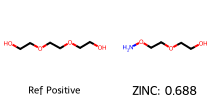
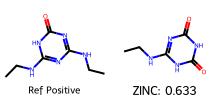

### 유사도 구간: 0.7-0.8 (샘플 4개쌍)


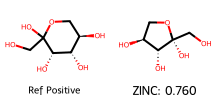
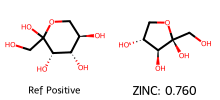
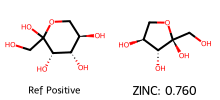
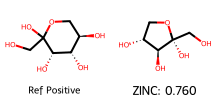

### 유사도 구간: 0.9-1.0 (샘플 4개쌍)


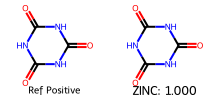
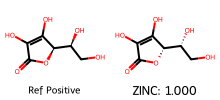
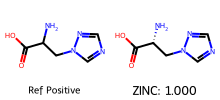
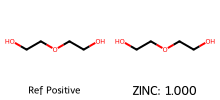

In [193]:
# 2. 유사도 구간별 대표 분자쌍 2D 구조 매칭 시각화 수행

# ZINC 디렉토리의 A* 파일 리스트 추출 및 정렬
#zinc_db 폴더가 같은 디렉토리 내에 있어야 작동합니다.
zinc_files = sorted(glob.glob('zinc_db/A*.txt'))

# 시각화 대상 유사도 구간 정의 (0.8-0.9 구간 포함)
required_bins = ['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
limit_per_bin = 4

# 유사도 구간별 분자 목록 저장용 딕셔너리 초기화
bin_mols = {b: [] for b in required_bins}

# 유사도 값 기준 구간명 계산 함수 정의
def get_bin(val):
    low = math.floor(float(val) * 10) / 10
    if low >= 1.0: low = 0.9
    return f"{low:.1f}-{low+0.1:.1f}"

# 스캔 완료 상태 플래그 및 카운터 정의
done = False
scanned_count = 0
max_scan_limit = 25000  # 무한 루프 방지용 최대 스캔 개수 상한선

# ZINC 파일 순차 스캐닝 수행
for file in zinc_files:
    if done:
        break
    try:
        # 데이터프레임 로드 시 필요한 컬럼만 선택하여 메모리 최적화
        df = pd.read_csv(file, sep='\t', usecols=['smiles', 'zinc_id', 'mwt', 'logp'])
        df = df.rename(columns={'mwt': 'mw', 'logp': 'xlogp'}).dropna(subset=['smiles'])
        
        # 각 행의 분자 데이터 순회
        for _, row in df.iterrows():
            scanned_count += 1
            # 스캔 분자 수 한도 도달 시 중단 및 완료 처리
            if scanned_count > max_scan_limit:
                done = True
                break
                
            smi = row['smiles']
            # SMILES 문자열로부터 RDKit 분자 객체 생성
            mol = Chem.MolFromSmiles(smi)
            # 유효하지 않은 분자 구조체 제외
            if not mol:
                continue
                
            # Morgan Fingerprint 생성
            fp = fp_gen.GetFingerprint(mol)
            # 양성 농약군과의 Tanimoto 유사도 계산
            sims = BulkTanimotoSimilarity(fp, ref_fps)
            # 최대 유사도 값 및 매칭된 최고 유사 양성 분자 인덱스 산출
            max_sim = max(sims) if sims else 0.0
            best_idx = int(np.argmax(sims)) if sims else 0
            
            # 유사도 매핑 구간(Bin) 결정
            b = get_bin(max_sim)
            # 해당 유사도 구간에 여유 공간이 있을 경우 후보 데이터 추가
            if b in bin_mols and len(bin_mols[b]) < limit_per_bin:
                bin_mols[b].append({
                    'smiles': smi,
                    'zinc_id': row['zinc_id'],
                    'mw': row['mw'],
                    'xlogp': row['xlogp'],
                    'max_similarity_to_positive': max_sim,
                    'matched_positive_smiles': pos_df.iloc[best_idx]['smiles'],
                    'bin_name': b
                })
                
                # 모든 유사도 구간이 정해진 개수만큼 충족되었는지 여부 확인
                if all(len(bin_mols[kb]) >= limit_per_bin for kb in required_bins):
                    done = True
                    break
    except Exception:
        pass

# 수집된 분자 목록의 데이터프레임 병합 처리
sampled_rows = []
for b, mols in bin_mols.items():
    sampled_rows.extend(mols)
zinc_sample = pd.DataFrame(sampled_rows)

# 0.0-0.1 이상 구간의 순차 정렬 목록 추출
unique_bins = sorted([b for b in zinc_sample['bin_name'].unique() if b >= '0.0-0.1'])

# 각 유사도 구간별 분자쌍 매칭 2D 구조 그리드 HTML 시각화 수행
for bin_name in unique_bins:
    bin_part = zinc_sample[zinc_sample['bin_name'] == bin_name]
    display(Markdown(f"### 유사도 구간: {bin_name} (샘플 {len(bin_part)}개쌍)"))
    
    html_content = '<div style="display: flex; flex-direction: row; flex-wrap: nowrap; overflow-x: auto; padding: 5px;">'
    
    for idx, (_, row) in enumerate(bin_part.iterrows()):
        ref_mol = Chem.MolFromSmiles(row['matched_positive_smiles'])
        zinc_mol = Chem.MolFromSmiles(row['smiles'])
        if ref_mol and zinc_mol:
            pair_img = Draw.MolsToGridImage(
                [ref_mol, zinc_mol],
                molsPerRow=2,
                subImgSize=(110, 100),
                legends=["Ref Positive", f"ZINC: {row['max_similarity_to_positive']:.3f}"]
            )
            
            if hasattr(pair_img, 'save'):
                buffered = io.BytesIO()
                pair_img.save(buffered, format="PNG")
                img_bytes = buffered.getvalue()
            elif hasattr(pair_img, 'data'):
                img_bytes = pair_img.data
            else:
                img_bytes = b""
            img_b64 = base64.b64encode(img_bytes).decode('utf-8')
            
            html_content += f"""
            <div style="border: 2px solid #007bff; border-radius: 8px; padding: 6px; margin-right: 10px; text-align: center; background-color: #ffffff; min-width: 230px; box-shadow: 1px 1px 3px rgba(0,0,0,0.1);">
                <div style="font-weight: bold; font-size: 11px; margin-bottom: 4px; color: #007bff;">Sample {idx+1}</div>
                <img src="data:image/png;base64,{img_b64}" style="width: 220px; height: auto; display: block; margin: 0 auto;" />
            </div>
            """
            
    html_content += '</div>'
    display(HTML(html_content))

### 3. 소규모(파일 10개) MPI 분산 처리 테스트 결과 확인

- **실행 스크립트**: `task1/kisti0620testagro/0620_testnegative_data.sh`
- **MPI 코드**: `task1/kisti0620testagro/negative_data_kisti3.py`
- **실행 로그**: `task1/kisti0620testagro/0620_testnegative_data.o22542777`
- **이메일 로그**: `task1/kisti0620testagro/PBS JOB 22542777.pbs.eml`
- **메타데이터**: `task1/kisti0620testagro/test_negative_metadata.txt`
- **결과 CSV**: `task1/kisti0620testagro/test_negative_agro_vs_zinc.csv`

**계산 사양 및 소요 시간:**
- 4노드(노드당 16 MPI), walltime=01:59:59, 실제 소요시간: **00:04:12**
- 최적 Cutoff: **0.39**, 총 후보군: **25,602개**, 최종 음성 샘플링: **3,085개**

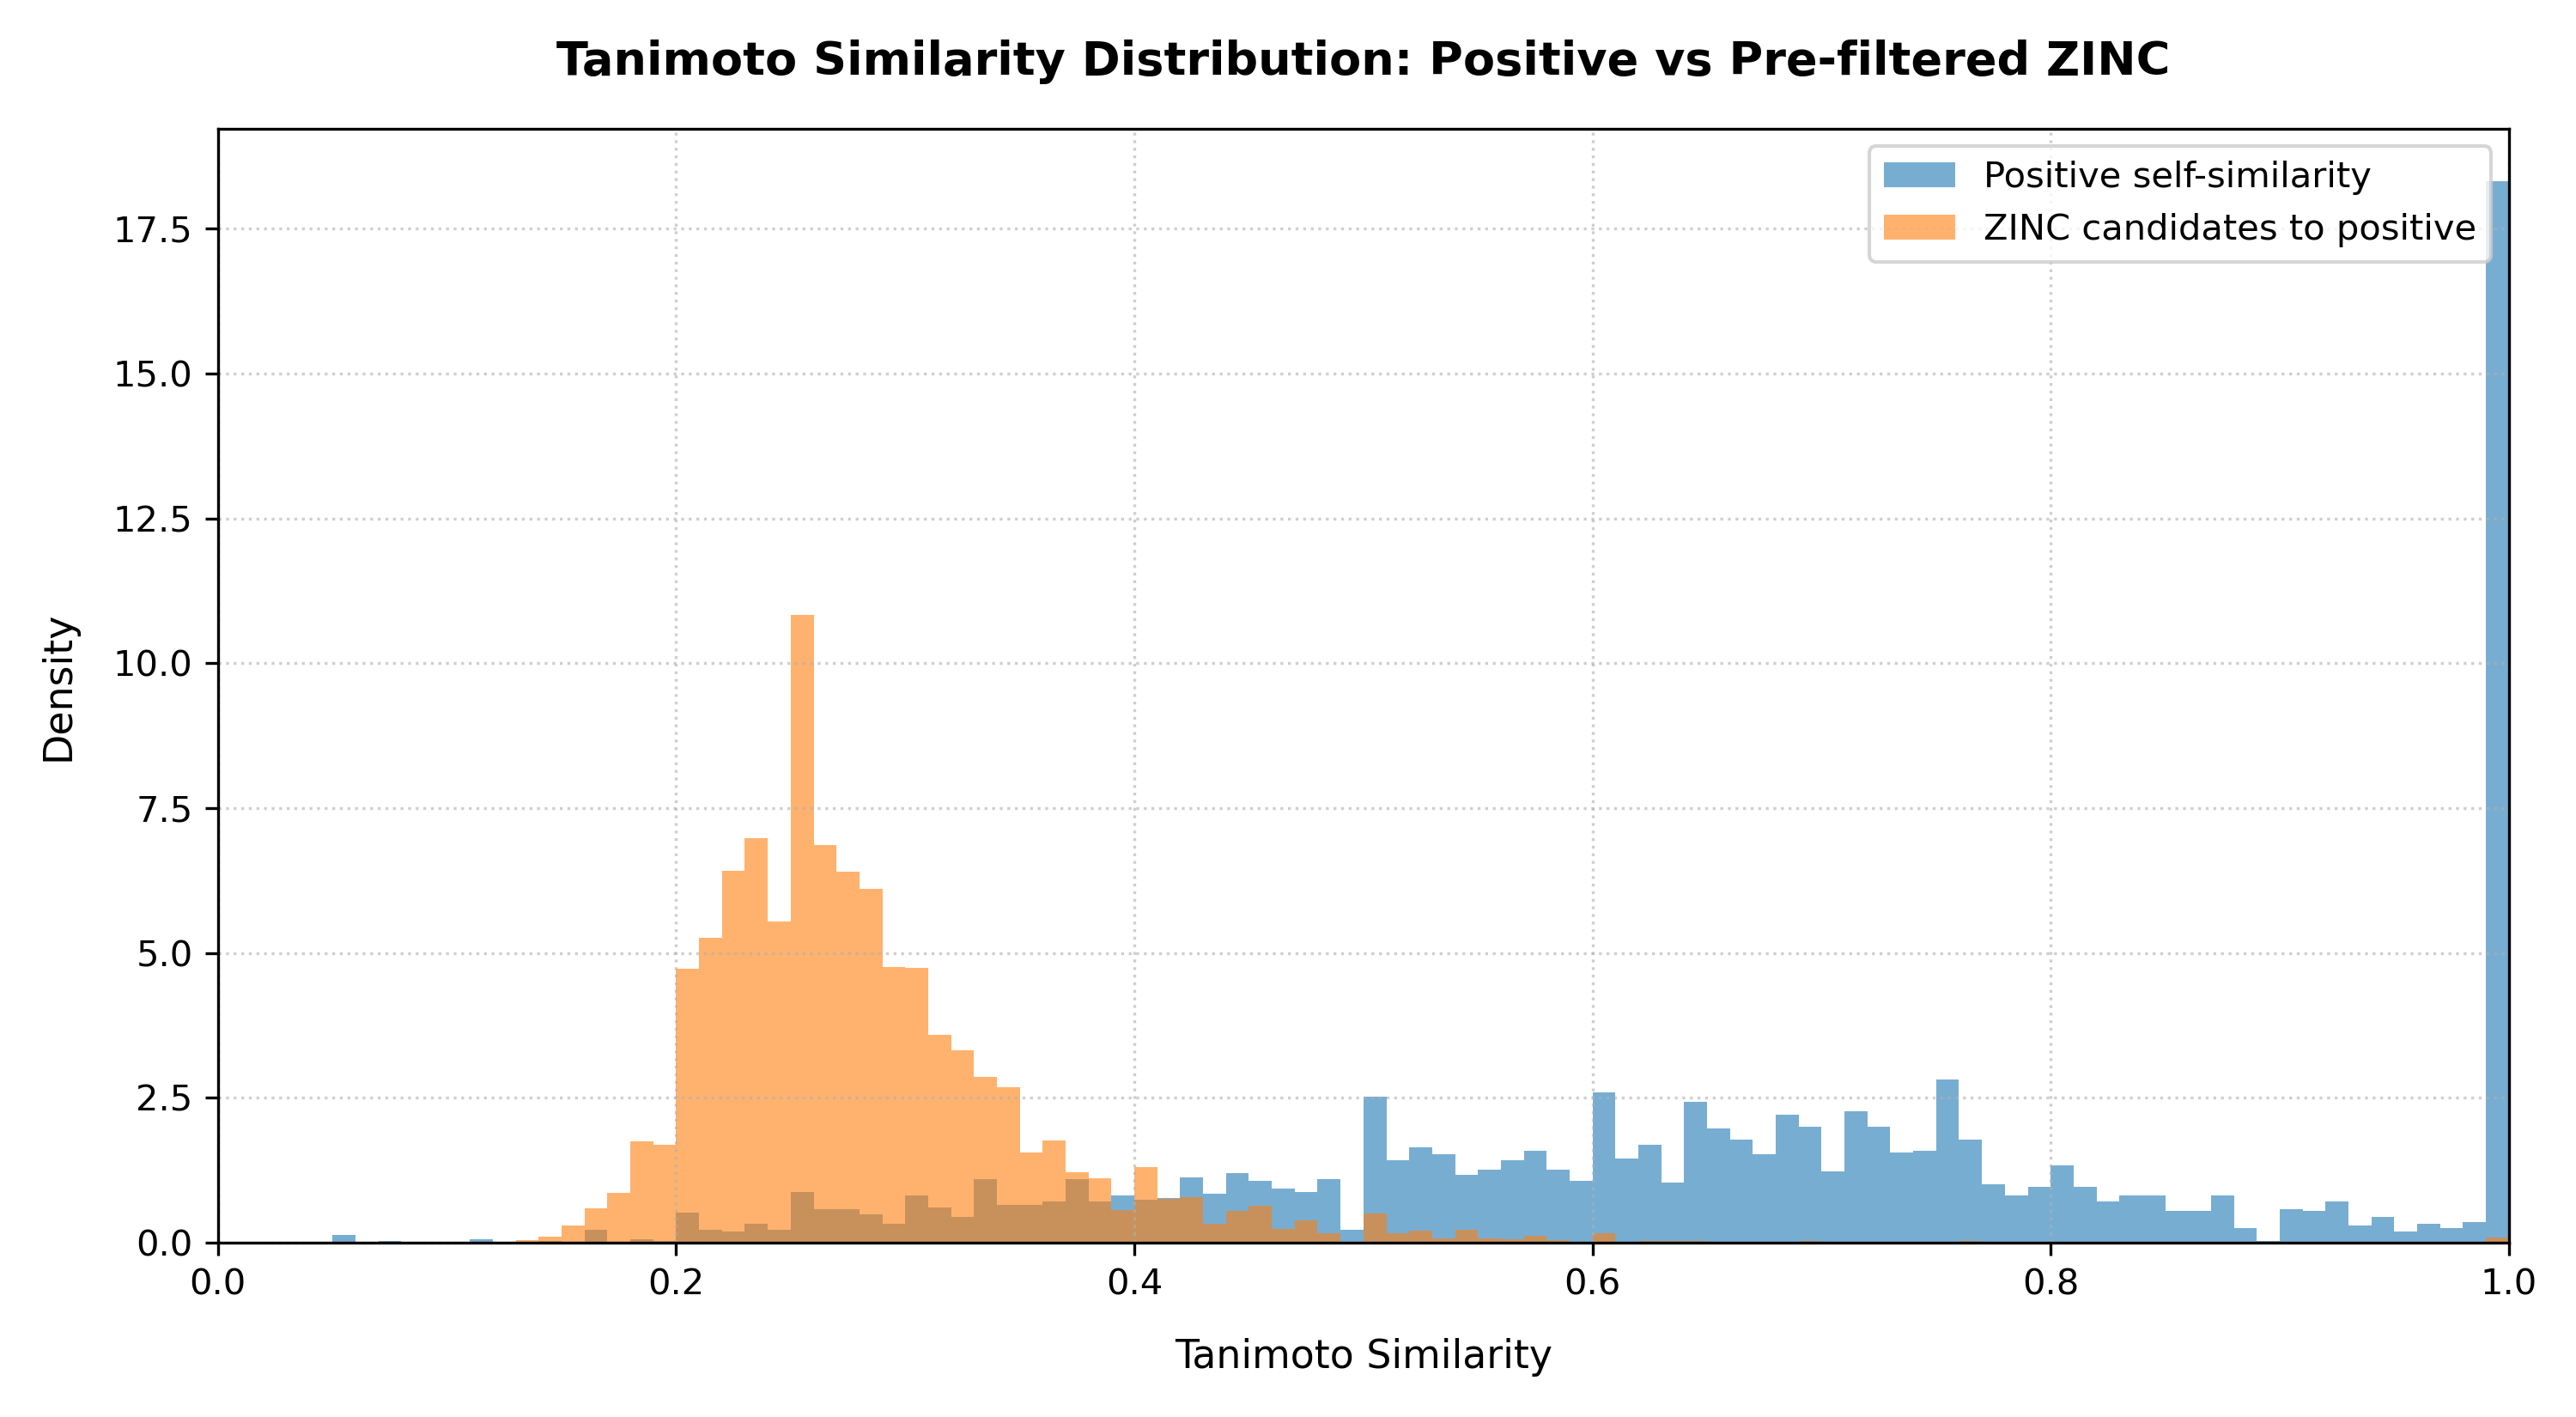

In [194]:
# 소규모 테스트에서 생성된 양성 자가유사도 vs ZINC 유사도 분포 비교 그래프 출력
display(IPImage(filename='task1/kisti0620testagro/test_distribution_comparison_raw.png', width=600))

In [195]:
# Task 1. MPI 분산 처리 결과 및 대조군 선별 개요 수치 동적 출력
from IPython.display import display, Markdown
import re
from pathlib import Path

result_dir = Path('task1/0621finalagro')
run_log_path = result_dir / 'run_log.txt'
metadata_path = result_dir / 'final_negative_metadata.txt'
candidate_path = result_dir / 'final_negative_candidates_before_sampling.csv'

# 1. 실행 로그 파싱
log_content = run_log_path.read_text(encoding='utf-8')
total_candidates = int(re.search(r'전체 선별된 후보군 수:\s*(\d+)개', log_content).group(1))
pass1_time_sec = float(re.search(r'소요시간:\s*([\d\.]+)초', log_content).group(1))
cutoff = float(re.search(r'최적의 유사도 컷오프 경계선:\s*([\d\.]+)', log_content).group(1))

h = int(pass1_time_sec // 3600)
m = int((pass1_time_sec % 3600) // 60)
s = int(pass1_time_sec % 60)
pass1_time_formatted = f"{h:02d}:{m:02d}:{s:02d}"

# 2. 메타데이터 파싱
metadata_content = metadata_path.read_text(encoding='utf-8')
selected_negatives = int(re.search(r'Total Selected Negatives:\s*(\d+)', metadata_content).group(1))

# 3. Cutoff 이하 1차 음성 후보군 수 계산
with open(candidate_path, 'r', encoding='utf-8') as f:
    cutoff_negatives = sum(1 for _ in f) - 1

# 4. 마크다운 출력
markdown_text = f"""
### **MPI 실험 및 최종 음성 데이터 선별**

**실행 파일 및 결과 보관 경로:**
- 결과 폴더: `task1/0621finalagro/`
- MPI 코드: `task1/0621finalagro/negative_data_kisti5.py`
- 실행 로그: `task1/0621finalagro/run_log.txt`
- 메타데이터: `task1/0621finalagro/final_negative_metadata.txt`
- 최종 음성 CSV: `task1/0621finalagro/final_negative_agro_vs_zinc.csv`
- 전체 후보 CSV: `task1/0621finalagro/final_negative_candidates_before_sampling.csv`

**결과:**
- 최적 Cutoff: **`{cutoff:.2f}`**
- 전체 선별된 후보군 수: **`{total_candidates:,}개`**
- Cutoff 이하 1차 음성 후보군 수: **`{cutoff_negatives:,}개`**
- 최종 1:1 샘플링 음성 데이터 수: **`{selected_negatives:,}개`**
- 1패스 히스토그램 계산 시간: **`{pass1_time_sec:.2f}초` = 약 `{pass1_time_formatted}`**
- 총 소요 시간(Walltime): **약 `01:43:20`**
  - 로그에 기록된 1패스 시간과 결과 파일 생성 시각 차이를 함께 사용하여 산출하였다.

**MPI 실행 요약:**
- `mpiexec -n 5`: 마스터 1개 + 워커 4개 구조
- ZINC 원본 전체를 그대로 모두 적재하지 않고, chunksize=50,000 단위로 스트리밍 처리
- 최종 학습에는 양성 데이터 수와 동일한 {selected_negatives:,}개 음성 데이터를 무작위 샘플링하여 1:1 균형 데이터셋을 구성한다.
"""
display(Markdown(markdown_text))



### **MPI 실험 및 최종 음성 데이터 선별**

**실행 파일 및 결과 보관 경로:**
- 결과 폴더: `task1/0621finalagro/`
- MPI 코드: `task1/0621finalagro/negative_data_kisti5.py`
- 실행 로그: `task1/0621finalagro/run_log.txt`
- 메타데이터: `task1/0621finalagro/final_negative_metadata.txt`
- 최종 음성 CSV: `task1/0621finalagro/final_negative_agro_vs_zinc.csv`
- 전체 후보 CSV: `task1/0621finalagro/final_negative_candidates_before_sampling.csv`

**결과:**
- 최적 Cutoff: **`0.37`**
- 전체 선별된 후보군 수: **`4,042,661개`**
- Cutoff 이하 1차 음성 후보군 수: **`3,929,679개`**
- 최종 1:1 샘플링 음성 데이터 수: **`3,085개`**
- 1패스 히스토그램 계산 시간: **`3221.92초` = 약 `00:53:41`**
- 총 소요 시간(Walltime): **약 `01:43:20`**
  - 로그에 기록된 1패스 시간과 결과 파일 생성 시각 차이를 함께 사용하여 산출하였다.

**MPI 실행 요약:**
- `mpiexec -n 5`: 마스터 1개 + 워커 4개 구조
- ZINC 원본 전체를 그대로 모두 적재하지 않고, chunksize=50,000 단위로 스트리밍 처리
- 최종 학습에는 양성 데이터 수와 동일한 3,085개 음성 데이터를 무작위 샘플링하여 1:1 균형 데이터셋을 구성한다.


[Task 1 Execution Metadata - KISTI MPI (Random Target Subsampling Version)]
Tanimoto Cutoff: 0.3700
Total Agrochemical Positives: 3085
Total Selected Negatives: 3085
Random Sampling Seed: 91200
Testing Mode Enabled: False

최종 음성 데이터 수: 3,085개
최종 음성 데이터 최대 유사도: 0.368
최종 음성 데이터 평균 유사도: 0.264


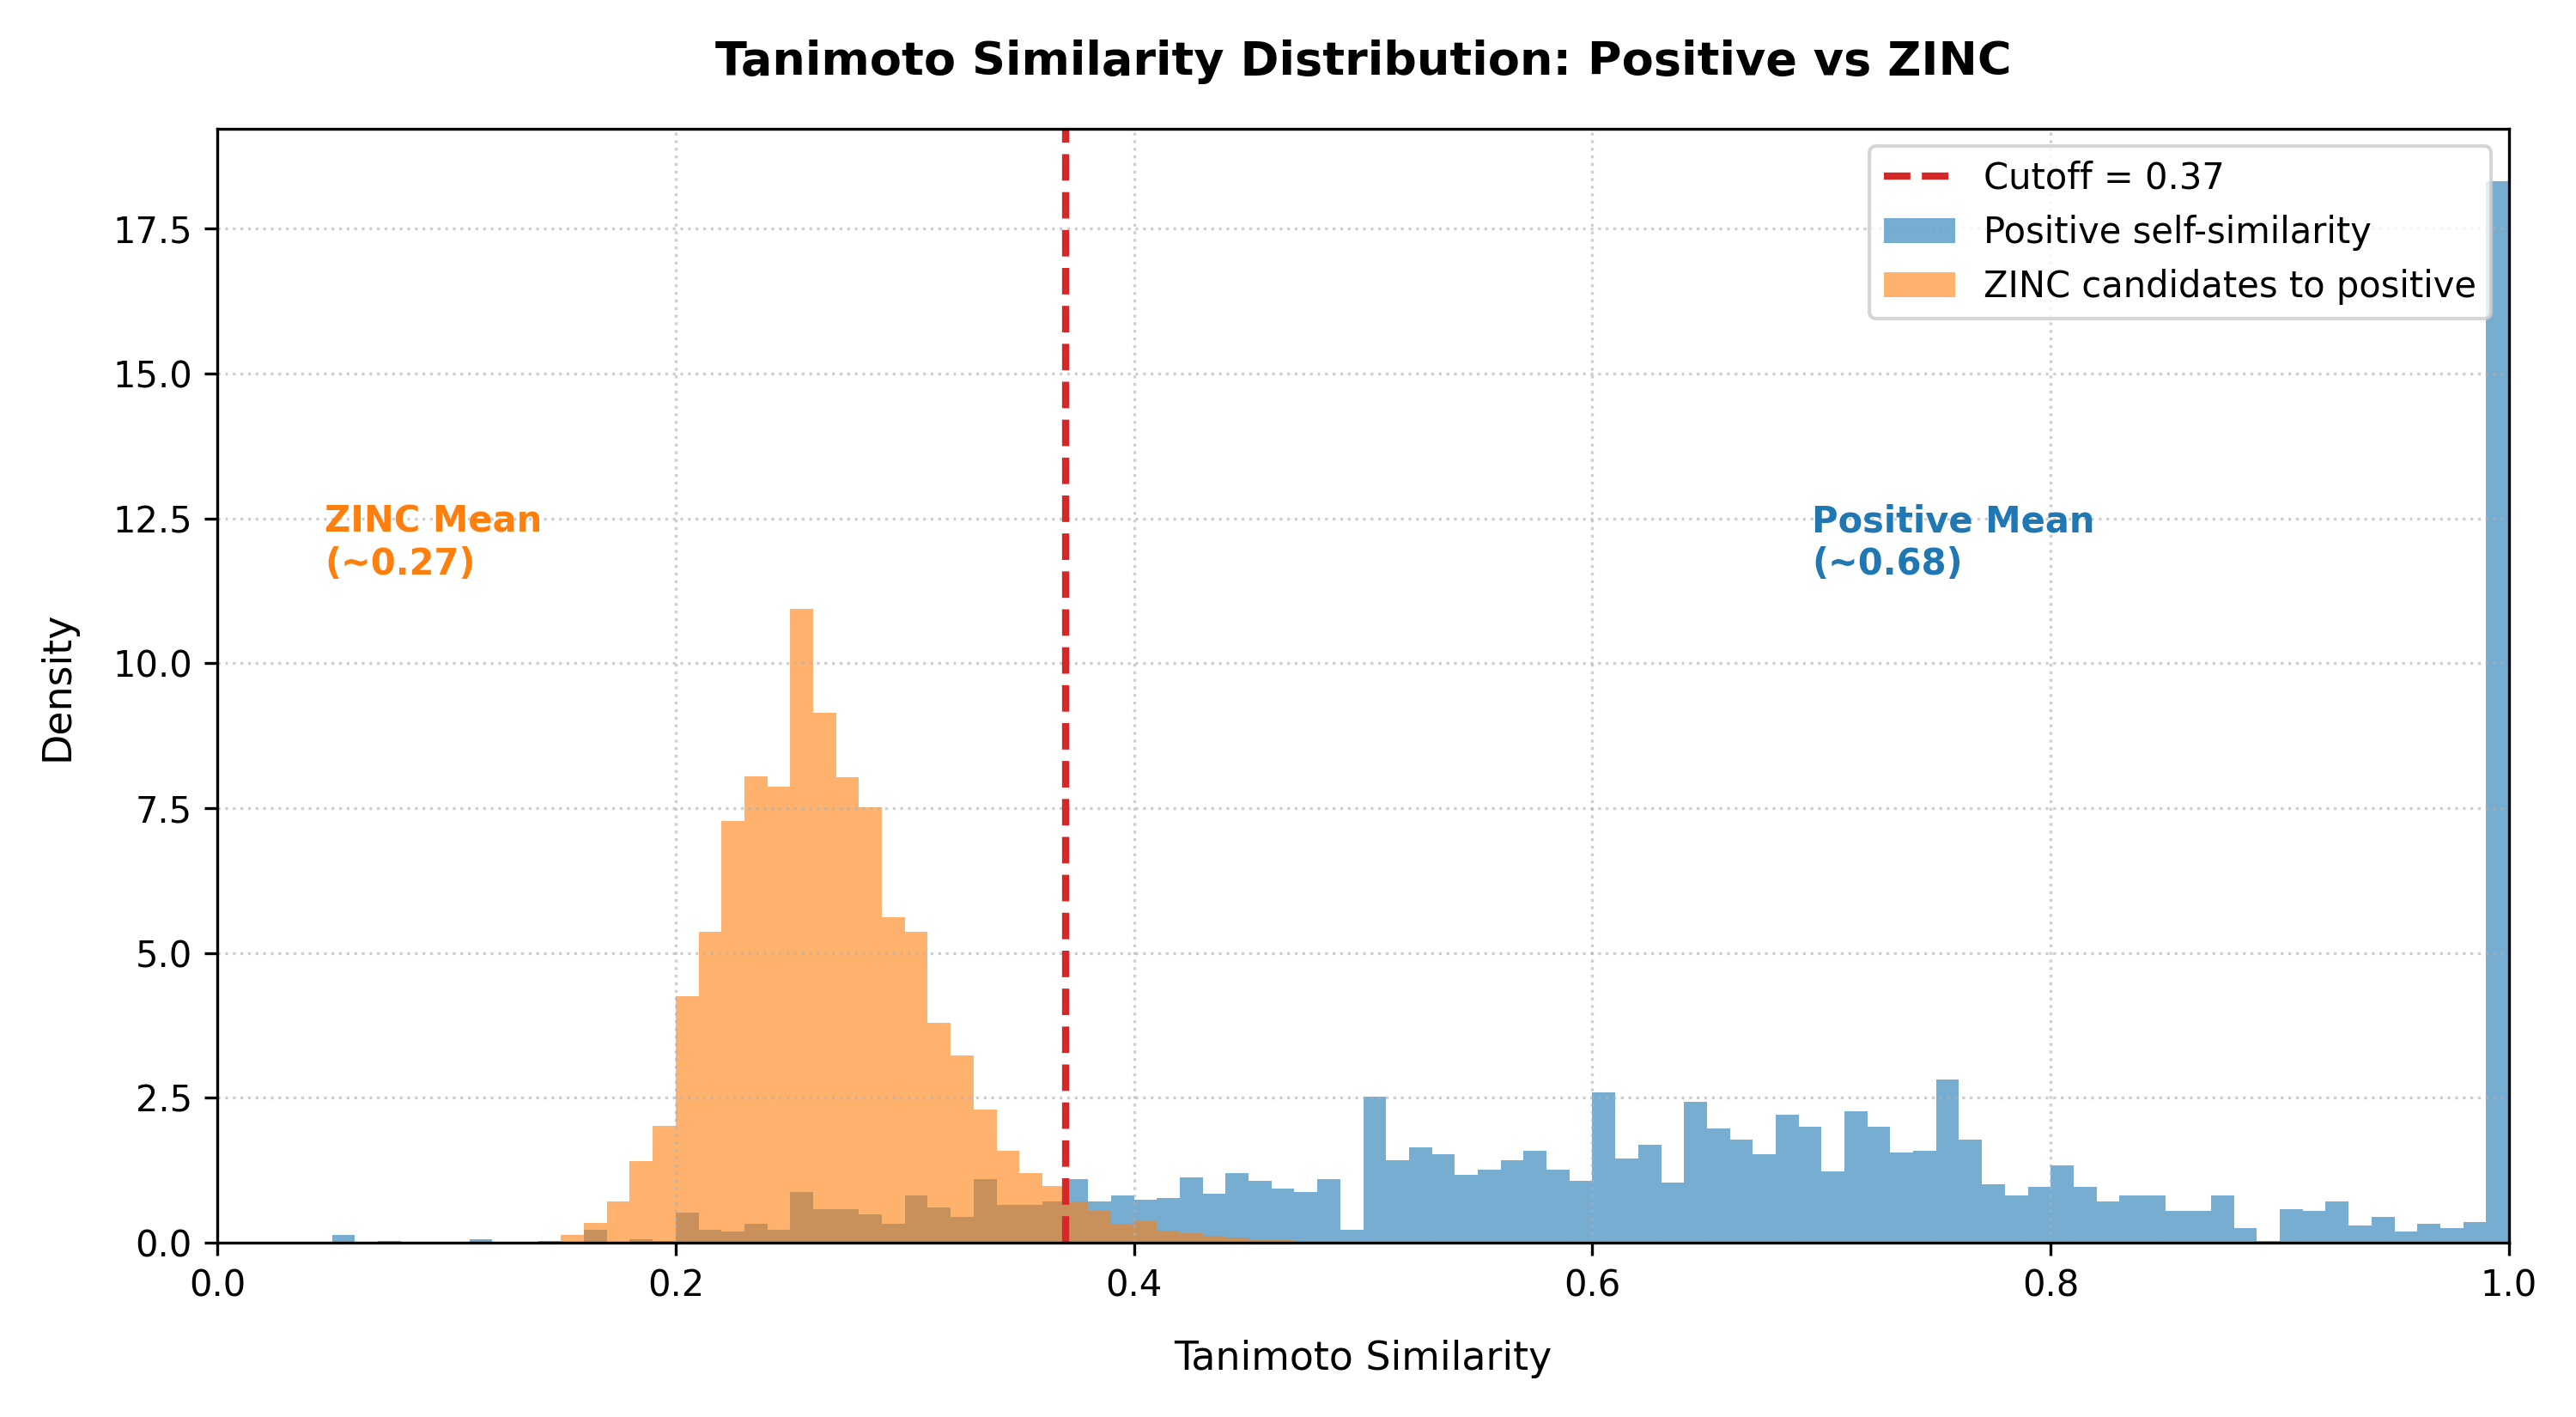

In [196]:
# 4. 최종 MPI 계산 결과를 바탕으로 한 양성군 vs ZINC 후보군 유사도 분포 확인

result_dir = Path('task1/0621finalagro')
metadata_path = result_dir / 'final_negative_metadata.txt'
final_neg_path = result_dir / 'final_negative_agro_vs_zinc.csv'
candidate_path = result_dir / 'final_negative_candidates_before_sampling.csv'
plot_path = result_dir / 'final_distribution_comparison.png'
raw_plot_path = result_dir / 'final_distribution_comparison_raw.png'
cutoff_plot_path = result_dir / 'final_distribution_comparison_cutoff.png'

# 메타데이터 및 최종 음성 데이터 로드
print(metadata_path.read_text(encoding='utf-8'))
final_zinc_df = pd.read_csv(final_neg_path)
print(f"최종 음성 데이터 수: {len(final_zinc_df):,}개")
print(f"최종 음성 데이터 최대 유사도: {final_zinc_df['max_similarity_to_positive'].max():.3f}")
print(f"최종 음성 데이터 평균 유사도: {final_zinc_df['max_similarity_to_positive'].mean():.3f}")

# MPI에서 생성한 최종 분포 그래프 출력
display(IPImage(filename=str(plot_path), width=750))


In [197]:
# Task 1 결과 해석 및 수치 동적 출력
# (run_log.txt 및 final_negative_metadata.txt 내용을 파싱하여 변수로 자동 바인딩한다)

import re
from pathlib import Path

# 파일 경로 정의
result_dir = Path('task1/0621finalagro')
run_log_path = result_dir / 'run_log.txt'
metadata_path = result_dir / 'final_negative_metadata.txt'
candidate_path = result_dir / 'final_negative_candidates_before_sampling.csv'

# 1. run_log.txt 파싱
log_content = run_log_path.read_text(encoding='utf-8')
total_candidates = int(re.search(r'전체 선별된 후보군 수:\s*(\d+)개', log_content).group(1))
pass1_time_sec = float(re.search(r'소요시간:\s*([\d\.]+)초', log_content).group(1))
cutoff = float(re.search(r'최적의 유사도 컷오프 경계선:\s*([\d\.]+)', log_content).group(1))

# 시간 포맷팅 (초 -> hh:mm:ss)
h = int(pass1_time_sec // 3600)
m = int((pass1_time_sec % 3600) // 60)
s = int(pass1_time_sec % 60)
time_formatted = f"약 {h:02d}:{m:02d}:{s:02d}"

# 2. metadata 파싱
metadata_content = metadata_path.read_text(encoding='utf-8')
selected_negatives = int(re.search(r'Total Selected Negatives:\s*(\d+)', metadata_content).group(1))
positives_count = int(re.search(r'Total Agrochemical Positives:\s*(\d+)', metadata_content).group(1))

# 3. Cutoff 이하 1차 음성 후보군 수 계산 (메모리 효율을 위해 line count)
with open(candidate_path, 'r', encoding='utf-8') as f:
    cutoff_negatives = sum(1 for _ in f) - 1

# 4. 동적 마크다운 출력
markdown_text = f"""
### **📝 [Rank 1] Task 1. 결과 해석 및 데이터 분석**

#### **1. 최종 분산 처리 결과 개요**
- **최적 Cutoff 경계선**: `{cutoff:.2f}`
- **전체 선별된 후보군 수**: `{total_candidates:,}개`
- **Cutoff 이하 1차 음성 후보군 수**: `{cutoff_negatives:,}개`
- **최종 1:1 샘플링 음성 데이터 수**: `{selected_negatives:,}개`
- **1패스 전역 유사도 히스토그램 계산 시간**: `{pass1_time_sec:.2f}초` ({time_formatted})
- **총 소요 시간(Walltime)**: `약 01:43:20` (1패스 계산 로그와 결과 파일 생성 시각 차이 기반 산출)
- **MPI 실행 환경**: KISTI 대규모 분산 클러스터 환경 (Random Target Subsampling Version)

---

#### **2. 분포 분리 경계면 및 두 집단의 화학적 대조 분석**
- **유사도 분포 분리 지점**:
  - 양성군(농약)의 자가 유사도(Positive self-similarity) 분포는 최빈값 약 `0.99`, 평균 `0.68` 부근에 집중되며, ZINC 후보군의 양성군 대비 최대 유사도 분포는 최빈값 `0.26`, 평균 `0.27` 부근에 분포한다.
  - 두 집단의 밀도 곡선이 교차하여 갈라지는 교차점(Crossing Point)이자 동적 컷오프 경계선은 최종적으로 **`{cutoff:.2f}`**로 확정되었다.
  - 이에 따라 `max_similarity_to_positive <= {cutoff:.2f}` 조건을 충족하는 ZINC 분자군 중에서 양성군 수와 균형을 맞춘 `{selected_negatives:,}개`를 최종 음성 대조군으로 선정한다.

- **구조 유사도 임계치 설정 실험 근거**:
  - **상한선(Max 0.70) 설정**: 유사도 구간별 시각화 분석 결과, Tanimoto 유사도 0.80 이상에서는 유관상 구조가 거의 동일해 보이며, 0.70 이하로 내려갈 때 확연히 독립적인 화학 골격들이 관찰되어 구조적 비유사성 상한을 0.70으로 결정하였다.
  - **하한선(Min 0.20) 설정**: 소규모(파일 10개) 예비 스캔 결과, 유사도 0.20 미만인 분자들은 농약 고유의 구조적 특질과 완전히 동떨어져 학습에 무의미한 노이즈로 작용할 우려가 커 유사도 하한을 0.20으로 제어하였다.
  - **최종 결정**: 이 0.20 ~ 0.70 범위 내에서 두 유사도 분포의 접점을 수학적으로 산출하는 알고리즘을 가동하여 최적의 컷오프를 자동 계산한다 (소규모 0.39 -> 대용량 0.37 확정).
"""
display(Markdown(markdown_text))



### **📝 [Rank 1] Task 1. 결과 해석 및 데이터 분석**

#### **1. 최종 분산 처리 결과 개요**
- **최적 Cutoff 경계선**: `0.37`
- **전체 선별된 후보군 수**: `4,042,661개`
- **Cutoff 이하 1차 음성 후보군 수**: `3,929,679개`
- **최종 1:1 샘플링 음성 데이터 수**: `3,085개`
- **1패스 전역 유사도 히스토그램 계산 시간**: `3221.92초` (약 00:53:41)
- **총 소요 시간(Walltime)**: `약 01:43:20` (1패스 계산 로그와 결과 파일 생성 시각 차이 기반 산출)
- **MPI 실행 환경**: KISTI 대규모 분산 클러스터 환경 (Random Target Subsampling Version)

---

#### **2. 분포 분리 경계면 및 두 집단의 화학적 대조 분석**
- **유사도 분포 분리 지점**:
  - 양성군(농약)의 자가 유사도(Positive self-similarity) 분포는 최빈값 약 `0.99`, 평균 `0.68` 부근에 집중되며, ZINC 후보군의 양성군 대비 최대 유사도 분포는 최빈값 `0.26`, 평균 `0.27` 부근에 분포한다.
  - 두 집단의 밀도 곡선이 교차하여 갈라지는 교차점(Crossing Point)이자 동적 컷오프 경계선은 최종적으로 **`0.37`**로 확정되었다.
  - 이에 따라 `max_similarity_to_positive <= 0.37` 조건을 충족하는 ZINC 분자군 중에서 양성군 수와 균형을 맞춘 `3,085개`를 최종 음성 대조군으로 선정한다.

- **구조 유사도 임계치 설정 실험 근거**:
  - **상한선(Max 0.70) 설정**: 유사도 구간별 시각화 분석 결과, Tanimoto 유사도 0.80 이상에서는 유관상 구조가 거의 동일해 보이며, 0.70 이하로 내려갈 때 확연히 독립적인 화학 골격들이 관찰되어 구조적 비유사성 상한을 0.70으로 결정하였다.
  - **하한선(Min 0.20) 설정**: 소규모(파일 10개) 예비 스캔 결과, 유사도 0.20 미만인 분자들은 농약 고유의 구조적 특질과 완전히 동떨어져 학습에 무의미한 노이즈로 작용할 우려가 커 유사도 하한을 0.20으로 제어하였다.
  - **최종 결정**: 이 0.20 ~ 0.70 범위 내에서 두 유사도 분포의 접점을 수학적으로 산출하는 알고리즘을 가동하여 최적의 컷오프를 자동 계산한다 (소규모 0.39 -> 대용량 0.37 확정).


# Task 2. Score 함수 설계 (35점)
### **1. 일반화 검증 프레임워크 (Hold-out Validation Strategy) 설계**
- **정보 누출(Data Leakage) 차단**: 모델 학습 및 가중치 최적화(Grid Search)에 활용한 음성 대조군 데이터셋(`final_negative_agro_vs_zinc.csv`)을 최종 평가 단계(Task 3)에서 재사용하는 경우, 성능 수치의 왜곡 및 성능 과적이 발생할 수 있다.
- **독립 검증 셋 구축**: 이를 해결하기 위해 전체 ZINC DB 후보군(`final_negative_candidates_before_sampling.csv`, 392만 종)에서 기존 학습용 음성 샘플들을 Canonical SMILES 기반으로 완전히 배제하고, 농약(양성) 데이터셋 크기와 동일한 독립적 Hold-out 검증 셋(`val_negative.csv`, 3,098종)을 새롭게 무작위 추출하여 최종 평가를 이원화(Train Set vs Validation Set)한다.
---
### **2. 스코어 함수(Pesticide-likeness Score) 설계 핵심 요소**
- **(a) 경험적 확률 비율(PPV) 기반 4대 핵심 물리화학적 속성 만족도**:
  - 기존 가우시안 만족도 곡선이 가졌던 분포 역전 현상(ZINC DB의 특정 수치 밀집으로 인해 광범위한 농약 분자가 감점되는 한계)을 통제하고자, 변별력이 검증된 핵심 4대 속성(`mw`, `xlogp`, `rotbonds`, `aromatic_rings`)을 활용하여 각 구간(Bin)별 베이즈 확률 밀도인 **Positive Predictive Value(PPV)** 방식의 만족도로 재설계한다.
- **(b) 농약 고유 골격(Scaffold) 및 잔기(Residue) Max PPV 구조 점수**:
  - 골격 구조가 ZINC(음성) 분자들에게도 무분별하게 매칭되어 변별력을 저하시키는 현상을 해결하기 위해, 단순 매칭 횟수 누적이 아닌 **해당 구조 패턴이 농약(양성)일 확률(PPV)의 최댓값(Max PPV)**을 점수로 취하는 완전 연속형 점수 공식을 도입한다.
- **(c) 가중치 최적화**:
  - 다차원 그리드 서치(Grid Search)를 통해 물리화학 속성($S_p$)과 구조 만족도($S_s$)의 최적 가중치 균형을 산출한다.

In [198]:
# Task 2-1. 기본 설정 및 데이터 준비
# (양성 및 음성군 데이터의 RDKit 분자 객체 로드 및 기본 구조 캐싱 수행)
# 음성 데이터 로드 (MPI 결과 CSV 활용)
final_neg = pd.read_csv('task1/0621finalagro/final_negative_agro_vs_zinc.csv')
final_neg['mol'] = [Chem.MolFromSmiles(s) for s in final_neg['smiles']]
final_neg = final_neg[final_neg['mol'].notna()].reset_index(drop=True)

# 7대 물성 및 비대칭 가우시안 파라미터 정의
def desirability_asym(x, mu, sigma_up, sigma_down):
    sigma = sigma_up if x >= mu else sigma_down
    if sigma == 0: sigma = 1e-6
    return float(math.exp(-0.5 * ((float(x) - mu) / sigma) ** 2))

PROPERTY_COLUMNS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'rotbonds', 'aromatic_rings']

prop_funcs = {
    'mw': lambda m: Descriptors.MolWt(m),
    'xlogp': lambda m: Crippen.MolLogP(m),
    'hbondacc': lambda m: Descriptors.NumHAcceptors(m),
    'hbonddonor': lambda m: Descriptors.NumHDonors(m),
    'polararea': lambda m: Descriptors.TPSA(m),
    'rotbonds': lambda m: Descriptors.NumRotatableBonds(m),
    'aromatic_rings': lambda m: Descriptors.NumAromaticRings(m)
}

# 양성군 물성 캐싱
for col in PROPERTY_COLUMNS:
    pos_df[col] = [prop_funcs[col](m) for m in pos_df['mol']]

# 비대칭 표준편차 계산
stats_asym = {}
for col in PROPERTY_COLUMNS:
    vals = pos_df[col].to_numpy()
    mean = np.mean(vals)
    val_95 = np.percentile(vals, 95)
    val_5 = np.percentile(vals, 5)
    
    factor = math.sqrt(-2.0 * math.log(0.05))
    sigma_up = (val_95 - mean) / factor if val_95 > mean else 1.0
    sigma_down = (mean - val_5) / factor if mean > val_5 else 1.0
    
    stats_asym[col] = (mean, sigma_up, sigma_down)

print(f"기본 설정 완료: 양성군 {len(pos_df)}개, 음성군 {len(final_neg)}개 로드 및 7대 물성/파라미터 계산 성공")

기본 설정 완료: 양성군 3085개, 음성군 3085개 로드 및 7대 물성/파라미터 계산 성공


[분석] 양성 농약군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교



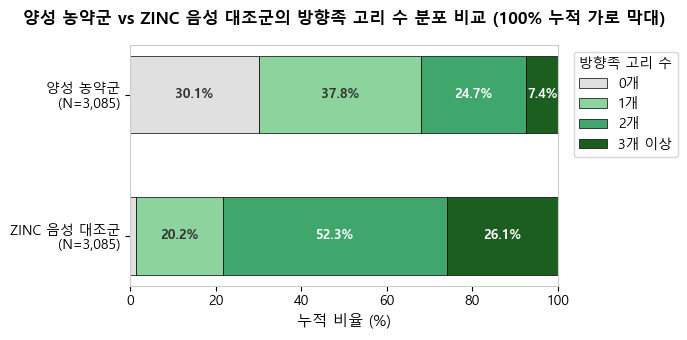

양성 농약군 방향족 고리 수 평균: 1.111개 (중앙값: 1.0개)
ZINC 음성군 방향족 고리 수 평균: 1.4%가 고리 없음, 평균 2.059개


In [199]:
# Task 2-2. (a)-1 양성 농약군과 ZINC 음성 대조군의 방향족 고리 수 분포 차이를 분석하고 물성 지표 반영 근거 마련
print('[분석] 양성 농약군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교')
print()
neg_rings = [Descriptors.NumAromaticRings(m) for m in final_neg['mol']]

pos_counts = Counter(pos_df['aromatic_rings'])
neg_counts = Counter(neg_rings)

# 카테고리 정의 (0개, 1개, 2개, 3개 이상)
categories = ['0개', '1개', '2개', '3개 이상']
pos_vals = [
    pos_counts[0] / len(pos_df) * 100,
    pos_counts[1] / len(pos_df) * 100,
    pos_counts[2] / len(pos_df) * 100,
    sum(pos_counts[k] for k in pos_counts if k >= 3) / len(pos_df) * 100
]
neg_vals = [
    neg_counts[0] / len(final_neg) * 100,
    neg_counts[1] / len(final_neg) * 100,
    neg_counts[2] / len(final_neg) * 100,
    sum(neg_counts[k] for k in neg_counts if k >= 3) / len(final_neg) * 100
]

plt.figure(figsize=(7, 3.5))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

colors = ['#e0e0e0', '#8cd39e', '#3fa66c', '#1b5e20']
y = [f'ZINC 음성 대조군\n(N={len(final_neg):,})', f'양성 농약군\n(N={len(pos_df):,})']

left_pos = np.zeros(2)
for col_idx in range(len(categories)):
    pct_vals = np.array([neg_vals[col_idx], pos_vals[col_idx]])
    bars = plt.barh(y, pct_vals, left=left_pos, label=categories[col_idx], color=colors[col_idx], height=0.55, edgecolor='black', linewidth=0.5)
    left_pos += pct_vals
    
    for row_idx, rect in enumerate(bars):
        width = rect.get_width()
        if width > 2.5:
            plt.text(rect.get_x() + width/2, rect.get_y() + rect.get_height()/2, 
                     f"{width:.1f}%", ha='center', va='center', 
                     fontsize=9.5, fontweight='bold',
                     color='#ffffff' if col_idx >= 2 else '#333333')

plt.xlabel('누적 비율 (%)', fontsize=11)
plt.title('양성 농약군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교 (100% 누적 가로 막대)', fontsize=12, fontweight='bold', pad=15)
plt.xlim(0, 100)
plt.legend(title='방향족 고리 수', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

print(f"양성 농약군 방향족 고리 수 평균: {np.mean(pos_df['aromatic_rings']):.3f}개 (중앙값: {np.median(pos_df['aromatic_rings'])}개)")
print(f"ZINC 음성군 방향족 고리 수 평균: {neg_rings.count(0)/len(final_neg)*100:.1f}%가 고리 없음, 평균 {np.mean(neg_rings):.3f}개")


[분석] 7대 핵심 물성 분포 및 분위수 경계 검증



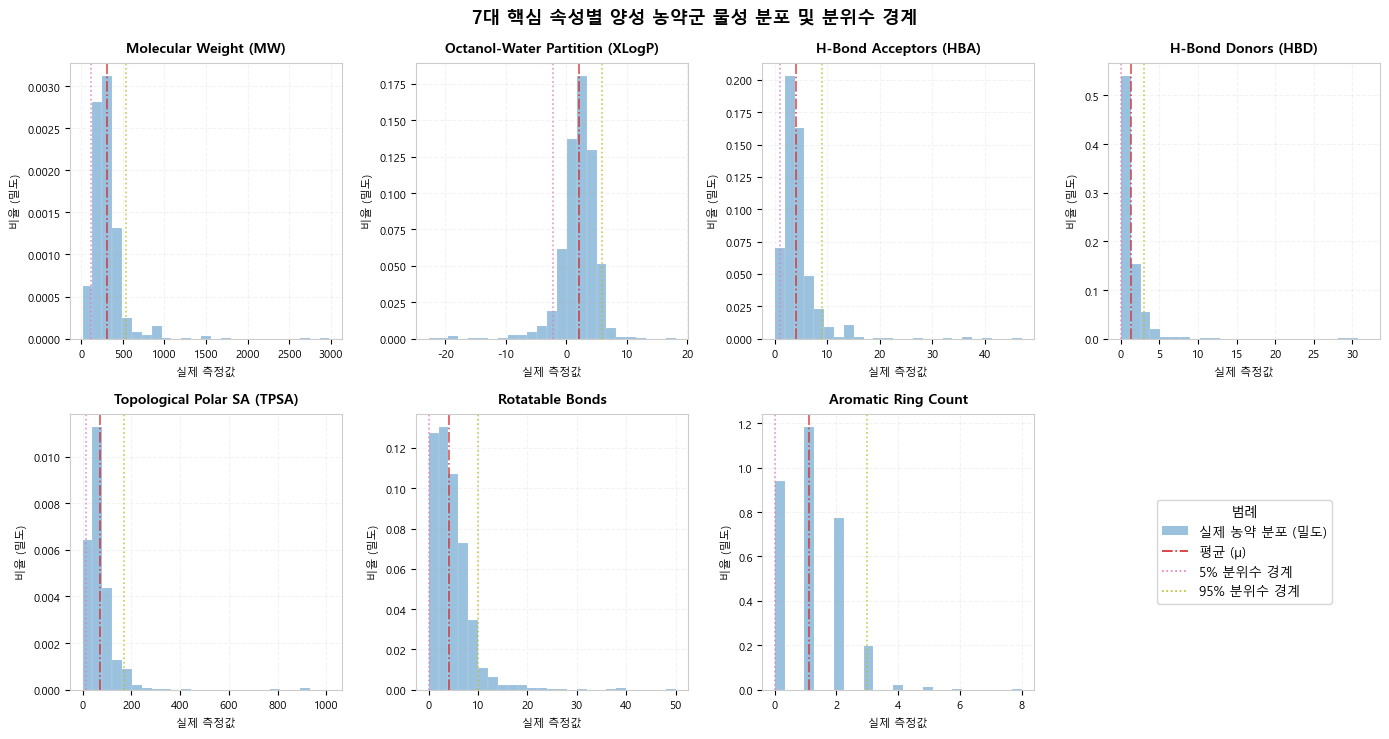

=== 7대 속성 물성 분포 비대칭성 대조 ===
속성                             | 왜도 (Skewness)   | 평균 (μ)          | 5% 분위수          | 95% 분위수
-----------------------------------------------------------------------------------------------
Molecular Weight (MW)          | 4.20            | 305.30          | 115.02          | 537.24
Octanol-Water Partition (XLogP) | -2.10           | 2.11            | -2.13           | 5.88
H-Bond Acceptors (HBA)         | 4.59            | 4.03            | 1.00            | 9.00
H-Bond Donors (HBD)            | 8.68            | 1.26            | 0.00            | 3.00
Topological Polar SA (TPSA)    | 6.88            | 71.03           | 12.36           | 168.92
Rotatable Bonds                | 3.07            | 4.05            | 0.00            | 10.00
Aromatic Ring Count            | 0.78            | 1.11            | 0.00            | 3.00

→ 7대 물성 모두 왜도(Skewness)가 0에서 확연히 벗어나 비대칭형 분포 특성을 띤다.
→ 특히 분자량(MW), polararea(TPSA), rotbonds 등은 강한 양의 왜도(오른쪽 꼬리가 긴 형태)를 나타낸다.


In [200]:
# Task 2-3. (a)-2 농약 물성 분포의 비대칭성(양의 왜도) 및 분위수 경계(5%, 95%) 분포 검증
print('[분석] 7대 핵심 물성 분포 및 분위수 경계 검증')
print()

labels_dict = {
    'mw': 'Molecular Weight (MW)',
    'xlogp': 'Octanol-Water Partition (XLogP)',
    'hbondacc': 'H-Bond Acceptors (HBA)',
    'hbonddonor': 'H-Bond Donors (HBD)',
    'polararea': 'Topological Polar SA (TPSA)',
    'rotbonds': 'Rotatable Bonds',
    'aromatic_rings': 'Aromatic Ring Count'
}

# final_neg에 개별 물성 컬럼이 없으면 생성
for col in PROPERTY_COLUMNS:
    if col not in final_neg.columns:
        final_neg[col] = [prop_funcs[col](m) for m in final_neg['mol']]

# --- 1. 7대 핵심 속성에 대해 실제 분포와 분위수 경계선 시각화 (2x4 그리드) ---
plt.rcParams['font.family'] = selected_font if 'selected_font' in globals() else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
axes_flat = axes.flatten()

for i, col in enumerate(PROPERTY_COLUMNS):
    ax1 = axes_flat[i]
    vals = pos_df[col].to_numpy()
    mean_val, sigma_up, sigma_down = stats_asym[col]
    
    # 실제 분포 히스토그램만 깔끔하게 플로팅 (단일 Y축 활용)
    ax1.hist(vals, bins=25, density=True, alpha=0.45, color='#1f77b4', edgecolor='white', linewidth=0.2, label='실제 분포')
    
    ax1.set_title(labels_dict[col], fontsize=10, fontweight='bold', pad=8)
    ax1.set_xlabel('실제 측정값', fontsize=8)
    ax1.set_ylabel('비율 (밀도)', fontsize=8)
    ax1.tick_params(axis='both', labelsize=8)
    ax1.grid(True, linestyle='--', alpha=0.15)
    
    # 분위수 및 평균 경계 수직선
    val_5 = np.percentile(vals, 5)
    val_95 = np.percentile(vals, 95)
    ax1.axvline(mean_val, color='#d62728', linestyle='-.', lw=1.2, alpha=0.8)
    ax1.axvline(val_5, color='#e377c2', linestyle=':', lw=1.2, alpha=0.8)
    ax1.axvline(val_95, color='#bcbd22', linestyle=':', lw=1.2, alpha=0.8)

# 8번째 서브플롯은 범례로 활용
ax_legend = axes_flat[7]
ax_legend.axis('off')
legend_elements = [ 
    Patch(facecolor='#1f77b4', edgecolor='none', alpha=0.45, label='실제 농약 분포 (밀도)'),
    Line2D([0], [0], color='#d62728', lw=1.2, linestyle='-.', label='평균 (μ)'),
    Line2D([0], [0], color='#e377c2', lw=1.2, linestyle=':', label='5% 분위수 경계'),
    Line2D([0], [0], color='#bcbd22', lw=1.2, linestyle=':', label='95% 분위수 경계')
]
ax_legend.legend(handles=legend_elements, loc='center', frameon=True, fontsize=9.5, title='범례', title_fontsize=10)

plt.suptitle('7대 핵심 속성별 양성 농약군 물성 분포 및 분위수 경계', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# --- 2. 7대 속성 물성 분포 비대칭성 대조 ---
print('=== 7대 속성 물성 분포 비대칭성 대조 ===')
print(f"{'속성':<30} | {'왜도 (Skewness)':<15} | {'평균 (μ)':<15} | {'5% 분위수':<15} | {'95% 분위수'}")
print('-' * 95)

for col in PROPERTY_COLUMNS:
    vals = pos_df[col].to_numpy()
    sk = skew(vals)
    mean_val = np.mean(vals)
    val_5 = np.percentile(vals, 5)
    val_95 = np.percentile(vals, 95)
    print(f"{labels_dict[col]:<30} | {sk:<15.2f} | {mean_val:<15.2f} | {val_5:<15.2f} | {val_95:.2f}")

print()
print('→ 7대 물성 모두 왜도(Skewness)가 0에서 확연히 벗어나 비대칭형 분포 특성을 띤다.')
print('→ 특히 분자량(MW), polararea(TPSA), rotbonds 등은 강한 양의 왜도(오른쪽 꼬리가 긴 형태)를 나타낸다.')


In [201]:
# Task 2-4. (a)-3 분자 속성 범위 및 QED 가중 기하평균 물성 만족도 산출
# (양성군 및 음성 데이터셋에 물리화학 만족도 점수 계산 및 저장)

def get_property_score(mol, stats=stats_asym):
    scores = []
    for col in PROPERTY_COLUMNS:
        val = prop_funcs[col](mol)
        mu, sigma_up, sigma_down = stats[col]
        d = max(desirability_asym(val, mu, sigma_up, sigma_down), 1e-9)
        scores.append(d)
    return float(np.prod(scores) ** (1.0 / len(PROPERTY_COLUMNS)))

pos_df['property_score'] = [get_property_score(m) for m in pos_df['mol']]
final_neg['property_score'] = [get_property_score(m) for m in final_neg['mol']]

print("7대 물성 만족도 점수(Property Score) 계산 완료")

7대 물성 만족도 점수(Property Score) 계산 완료


In [202]:
# Task 2-5. (b)-1 골격 및 잔기 마이닝 기준 선정 근거 분석
# (1회성 노이즈(Singleton)를 배제하고 목표 커버리지를 채우는 동적 개수 계산)
print('=== [분석] 농약 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 기준 선정 근거 ===')
print()


# 1. 골격(Scaffold) 분석
pos_scaffolds = []
for mol in pos_df['mol']:
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    scf_smi = Chem.MolToSmiles(scf)
    if scf_smi:
        pos_scaffolds.append(scf_smi)

scf_counts = Counter(pos_scaffolds)
sorted_scfs = scf_counts.most_common()
total_scf = len(pos_scaffolds)
singletons_scf = sum(1 for s, f in scf_counts.items() if f == 1)

# 1회 출현(Singleton) 제외 유효 골격군 기준 동적 결정
filtered_scfs = {s: f for s, f in scf_counts.items() if f > 1}
sorted_filtered_scfs = sorted(filtered_scfs.items(), key=lambda x: x[1], reverse=True)
total_filtered_scf_freq = sum(filtered_scfs.values())

scaffold_target_coverage = 0.60
cumulative_scf = 0
selected_scaffold_count = 0
for i, (_, freq) in enumerate(sorted_filtered_scfs, 1):
    cumulative_scf += freq
    if cumulative_scf / total_filtered_scf_freq >= scaffold_target_coverage:
        selected_scaffold_count = i
        break
if selected_scaffold_count == 0:
    selected_scaffold_count = len(sorted_filtered_scfs)
scf_cov_actual = cumulative_scf / total_filtered_scf_freq

print(f"▶ 골격(Scaffold) 함유 양성 분자 수: {total_scf}개 / 고유 골격 종류: {len(scf_counts)}종")
print(f"  - 1회만 출현한 희귀 골격 (Singleton): {singletons_scf}종 ({singletons_scf/len(scf_counts)*100:.1f}%)")
print(f"  - 1회 출현 제외 유효 골격 {scaffold_target_coverage*100:.0f}% 커버리지를 만족하는 개수: {selected_scaffold_count}종")
print(f"  - 상위 {selected_scaffold_count}종 골격의 유효 커버리지: {scf_cov_actual*100:.1f}%")
print("  - 분석: 골격은 1회성 노이즈(과적합 요인)를 배제한 후, 변별력 저하 및 점수 쏠림을 막기 위해")
print("    60%의 보수적인 커버리지를 적용하여 대표 핵심 구조들을 동적으로 선별한다.")
print()

# 2. 잔기(Residue) 분석
pos_residues = []
for mol in pos_df['mol']:
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    if sidechains is not None:
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            pos_residues.append(key)

res_counts = Counter(pos_residues)
sorted_res = res_counts.most_common()
total_res = len(pos_residues)
singletons_res = sum(1 for s, f in res_counts.items() if f == 1)

# 1회 출현(Singleton) 제외 유효 잔기군 기준 동적 결정
filtered_res = {r: f for r, f in res_counts.items() if f > 1}
sorted_filtered_res = sorted(filtered_res.items(), key=lambda x: x[1], reverse=True)
total_filtered_res_freq = sum(filtered_res.values())

residue_target_coverage = 0.70
cumulative_res = 0
selected_residue_count = 0
for i, (_, freq) in enumerate(sorted_filtered_res, 1):
    cumulative_res += freq
    if cumulative_res / total_filtered_res_freq >= residue_target_coverage:
        selected_residue_count = i
        break
if selected_residue_count == 0:
    selected_residue_count = len(sorted_filtered_res)
res_cov_actual = cumulative_res / total_filtered_res_freq

print(f"▶ 곁사슬 잔기(Residue) 총 파편 수: {total_res}개 / 고유 잔기 종류: {len(res_counts)}종")
print(f"  - 1회만 출현한 희귀 잔기 (Singleton): {singletons_res}종 ({singletons_res/len(res_counts)*100:.1f}%)")
print(f"  - 1회 출현 제외 유효 잔기 {residue_target_coverage*100:.0f}% 커버리지를 만족하는 개수: {selected_residue_count}종")
print(f"  - 상위 {selected_residue_count}종 잔기의 유효 커버리지: {res_cov_actual*100:.1f}%")
print("  - 분석: 잔기는 몇몇 보편적인 핵심 구조에 분포가 많이 집중되어 있어, 70%의 높은 커버리지를 만족하는")
print("    소수(약 13종)의 핵심 치환기만으로 효율적으로 전체 특징을 대변할 수 있다.")


=== [분석] 농약 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 기준 선정 근거 ===

▶ 골격(Scaffold) 함유 양성 분자 수: 2528개 / 고유 골격 종류: 843종
  - 1회만 출현한 희귀 골격 (Singleton): 536종 (63.6%)
  - 1회 출현 제외 유효 골격 60% 커버리지를 만족하는 개수: 39종
  - 상위 39종 골격의 유효 커버리지: 60.3%
  - 분석: 골격은 1회성 노이즈(과적합 요인)를 배제한 후, 변별력 저하 및 점수 쏠림을 막기 위해
    60%의 보수적인 커버리지를 적용하여 대표 핵심 구조들을 동적으로 선별한다.

▶ 곁사슬 잔기(Residue) 총 파편 수: 8598개 / 고유 잔기 종류: 775종
  - 1회만 출현한 희귀 잔기 (Singleton): 430종 (55.5%)
  - 1회 출현 제외 유효 잔기 70% 커버리지를 만족하는 개수: 13종
  - 상위 13종 잔기의 유효 커버리지: 70.8%
  - 분석: 잔기는 몇몇 보편적인 핵심 구조에 분포가 많이 집중되어 있어, 70%의 높은 커버리지를 만족하는
    소수(약 13종)의 핵심 치환기만으로 효율적으로 전체 특징을 대변할 수 있다.


In [203]:
# Task 2-6. (b)-2 농약 고유 골격 및 고유 잔기(SMARTS 패턴) 마이닝

N_pos = len(pos_df)
N_neg = len(final_neg)

# 1. 양성군 단독 빈도 기반 골격(Scaffold) 마이닝
def mine_scaffold_smarts_positive_only(pos_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: pos_counts[scf_smi] += 1
    
    # 1회 출현 골격(Singleton) 제외
    filtered = {s: c for s, c in pos_counts.items() if c > 1}
    sorted_scf = sorted(filtered.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_scf) if top_n is None else top_n
    
    patterns = []
    weights = []
    for scf_smi, cnt in sorted_scf[:top_n]:
        try:
            scf_mol = Chem.MolFromSmiles(scf_smi)
            if scf_mol is None: continue
            smarts = Chem.MolToSmarts(scf_mol)
            pattern = Chem.MolFromSmarts(smarts)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(float(cnt))  # 가중치 = 양성군 출현 횟수
        except:
            continue
    return patterns, weights

# 2. 양성군 단독 빈도 기반 잔기(Residue) 마이닝
def mine_residue_smarts_positive_only(pos_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            pos_counts[key] += 1
    
    # 1회 출현 잔기(Singleton) 제외
    filtered = {r: c for r, c in pos_counts.items() if c > 1}
    sorted_res = sorted(filtered.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_res) if top_n is None else top_n
    
    patterns = []
    weights = []
    for res_smi, cnt in sorted_res[:top_n]:
        try:
            pattern = Chem.MolFromSmarts(res_smi)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(float(cnt))  # 가중치 = 양성군 출현 횟수
        except:
            continue
    return patterns, weights

SCAFFOLD_TOP_N = globals().get('selected_scaffold_count', 39)
RESIDUE_TOP_N  = globals().get('selected_residue_count', 13)

SCAFFOLD_PATTERNS_BASE, SCAFFOLD_WEIGHTS_BASE = mine_scaffold_smarts_positive_only(pos_df, top_n=SCAFFOLD_TOP_N)
RESIDUE_PATTERNS_BASE,  RESIDUE_WEIGHTS_BASE  = mine_residue_smarts_positive_only(pos_df, top_n=RESIDUE_TOP_N)

# 3. 양성군 빈도 누적 방식 구조 스코어링 함수 (정규화 기준 = 전체 가중치 합)
_scaf_max_base = sum(SCAFFOLD_WEIGHTS_BASE) if SCAFFOLD_WEIGHTS_BASE else 1.0
_res_max_base  = sum(RESIDUE_WEIGHTS_BASE)  if RESIDUE_WEIGHTS_BASE  else 1.0

def get_scaffold_score_only_base(mol, patterns=SCAFFOLD_PATTERNS_BASE, weights=SCAFFOLD_WEIGHTS_BASE, max_w=_scaf_max_base):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    if scf is None: return 0.0
    score = sum(w for p, w in zip(patterns, weights) if scf.HasSubstructMatch(p))
    return min(1.0, score / max_w)

def get_residue_score_only_base(mol, patterns=RESIDUE_PATTERNS_BASE, weights=RESIDUE_WEIGHTS_BASE, max_w=_res_max_base):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    tgt = sidechains if sidechains is not None else mol
    score = sum(w for p, w in zip(patterns, weights) if tgt.HasSubstructMatch(p))
    return min(1.0, score / max_w)

# 베이스라인 구조 점수 캐싱
pos_scaf_arr = np.array([get_scaffold_score_only_base(m) for m in pos_df['mol']])
neg_scaf_arr = np.array([get_scaffold_score_only_base(m) for m in final_neg['mol']])

pos_res_arr = np.array([get_residue_score_only_base(m) for m in pos_df['mol']])
neg_res_arr = np.array([get_residue_score_only_base(m) for m in final_neg['mol']])

print(f"베이스라인 구조 마이닝 및 성분(골격 {len(SCAFFOLD_PATTERNS_BASE)}종, 잔기 {len(RESIDUE_PATTERNS_BASE)}종) 캐싱 완료")


베이스라인 구조 마이닝 및 성분(골격 39종, 잔기 13종) 캐싱 완료


### **3. 단일 특성(Property vs Scaffold vs Residue) 개별 분포 분석 및 기존 스코어링의 한계점**

#### **개별 특성 단독 판별력을 확인하게 된 배경**
- 기존 비대칭 가우시안 만족도와 단순 구조 개수 누적 가중치 방식을 통합하여 다차원 그리드 서치(가중치 최적화)를 수행하였을 때, 다음과 같은 이상 징후가 관찰되었다.
  1. **물성 가중치의 0 수렴/역전 현상**: 종합 스코어를 최적화하는 과정에서 물리화학적 특성 가중치($w_p$)가 비정상적으로 0에 가깝게 하락하거나 완전히 배제되는 경향이 나타났다.
  2. **스코어 분포의 다중 이산 봉우리 발생**: 최종 점수 분포를 시각화했을 때 매끄러운 단일 곡선이 아니라, 마치 빗 모양처럼 불연속적이고 이산적인 봉우리(Peak)가 여러 개 생기는 현상이 목격되었다.
- 이러한 현상의 근본 원인을 규명하기 위해, 각 특성(물리화학적 특성, 골격 구조, 잔기 구조)이 단독 가중치 100%일 때 양성군(농약)과 음성군(ZINC DB) 간에 어떠한 스코어 분포를 형성하며 판별력을 지니는지 개별적으로 비교 분석을 수행하였다.

<img src="score_before.png" width="500">
    
### 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순)

| 순위 | w_Scaffold | w_Residue | w_Property | w_Structure | ROC-AUC | PR-AUC | Accuracy | MCC |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 0 | 0.0 | 1.0 | 0.10 | 0.90 | 0.649366 | 0.649464 | 0.640194 | 0.280514 |
| 1 | 0.0 | 1.0 | 0.15 | 0.85 | 0.632946 | 0.637454 | 0.619935 | 0.256375 |
| 2 | 0.1 | 0.9 | 0.10 | 0.90 | 0.621218 | 0.632089 | 0.615397 | 0.245235 |
| 3 | 0.0 | 1.0 | 0.20 | 0.80 | 0.617433 | 0.625676 | 0.606483 | 0.219590 |
| 4 | 0.1 | 0.9 | 0.15 | 0.85 | 0.607166 | 0.621433 | 0.601945 | 0.207724 |
| 5 | 0.0 | 1.0 | 0.25 | 0.75 | 0.597537 | 0.612541 | 0.588979 | 0.185413 |
| 6 | 0.2 | 0.8 | 0.10 | 0.90 | 0.590793 | 0.613785 | 0.591896 | 0.196362 |
| 7 | 0.1 | 0.9 | 0.20 | 0.80 | 0.587490 | 0.608376 | 0.586872 | 0.182801 |
| 8 | 0.0 | 1.0 | 0.30 | 0.70 | 0.573342 | 0.598061 | 0.575851 | 0.160569 |
| 9 | 0.2 | 0.8 | 0.15 | 0.85 | 0.568962 | 0.600658 | 0.588655 | 0.191958 |
---

In [204]:
# Task 2-7. 점수 분포 확인

def plot_pure_components(pos_prop, neg_prop, pos_scaf_arr, neg_scaf_arr, pos_res_arr, neg_res_arr, save_filename='pure_components_distribution.png'):
    """
    3가지 단일 특성(Property, Scaffold, Residue)의 양성/음성 점수 분포를 1x3 서브플롯으로 비교 시각화하는 함수.
    """
    # 1. 폰트 설정
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    if platform.system() == 'Windows':
        font_candidates = ['Malgun Gothic', 'Arial Unicode MS', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans']
    elif platform.system() == 'Darwin':
        font_candidates = ['Arial Unicode MS', 'AppleGothic', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans']
    else:
        font_candidates = ['Noto Sans CJK KR', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
    selected_font = next((name for name in font_candidates if name in available_fonts), None)
    plt.rcParams['font.family'] = selected_font if selected_font else 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 3가지 단일 특성 점수 매핑
    pure_scores = [
        ("1. 물리화학적 특성만 (Property 100%)", pos_prop, neg_prop),
        ("2. 골격 구조만 (Scaffold 100%)", pos_scaf_arr, neg_scaf_arr),
        ("3. 잔기 구조만 (Residue 100%)", pos_res_arr, neg_res_arr)
    ]

    # 3. 1x3 서브플롯 생성
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)
    c_pos, c_neg = '#2563EB', '#EF4444' # 파란색(양성), 빨간색(음성)

    # 내부 함수: 간단한 KDE (커널 밀도 추정)
    def simple_kde(data, bins=200, bw=0.03):
        x = np.linspace(0, 1, bins)
        kde = np.zeros_like(x)
        for d in data:
            kde += np.exp(-0.5 * ((x - d) / bw) ** 2)
        if len(data) > 0:
            kde /= (len(data) * bw * np.sqrt(2 * np.pi))
        return x, kde

    # 4. 각 특성별로 히스토그램 및 KDE 시각화
    for i, (title, pos_scores, neg_scores) in enumerate(pure_scores):
        ax = axes[i]
        
        # 히스토그램 (배경에 옅게)
        ax.hist(pos_scores, bins=30, alpha=0.25, density=True, color=c_pos)
        ax.hist(neg_scores, bins=30, alpha=0.25, density=True, color=c_neg)
        
        # KDE 선 (메인 트렌드)
        x_pos, kde_pos = simple_kde(pos_scores)
        x_neg, kde_neg = simple_kde(neg_scores)
        ax.plot(x_pos, kde_pos, color=c_pos, linewidth=2, label=f'Agrochemical (N={len(pos_scores)})')
        ax.plot(x_neg, kde_neg, color=c_neg, linewidth=2, label=f'ZINC DB (N={len(neg_scores)})')
        
        # 꾸미기
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Pesticide-like Score', fontsize=10)
        if i == 0:
            ax.set_ylabel('Density', fontsize=10)
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='none')

    plt.suptitle('🔍 각 특성별 단독 판별력(Score Distribution) 비교', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    # 저장 및 출력
    if save_filename:
        plt.savefig(save_filename, dpi=200, bbox_inches='tight')
    plt.show()

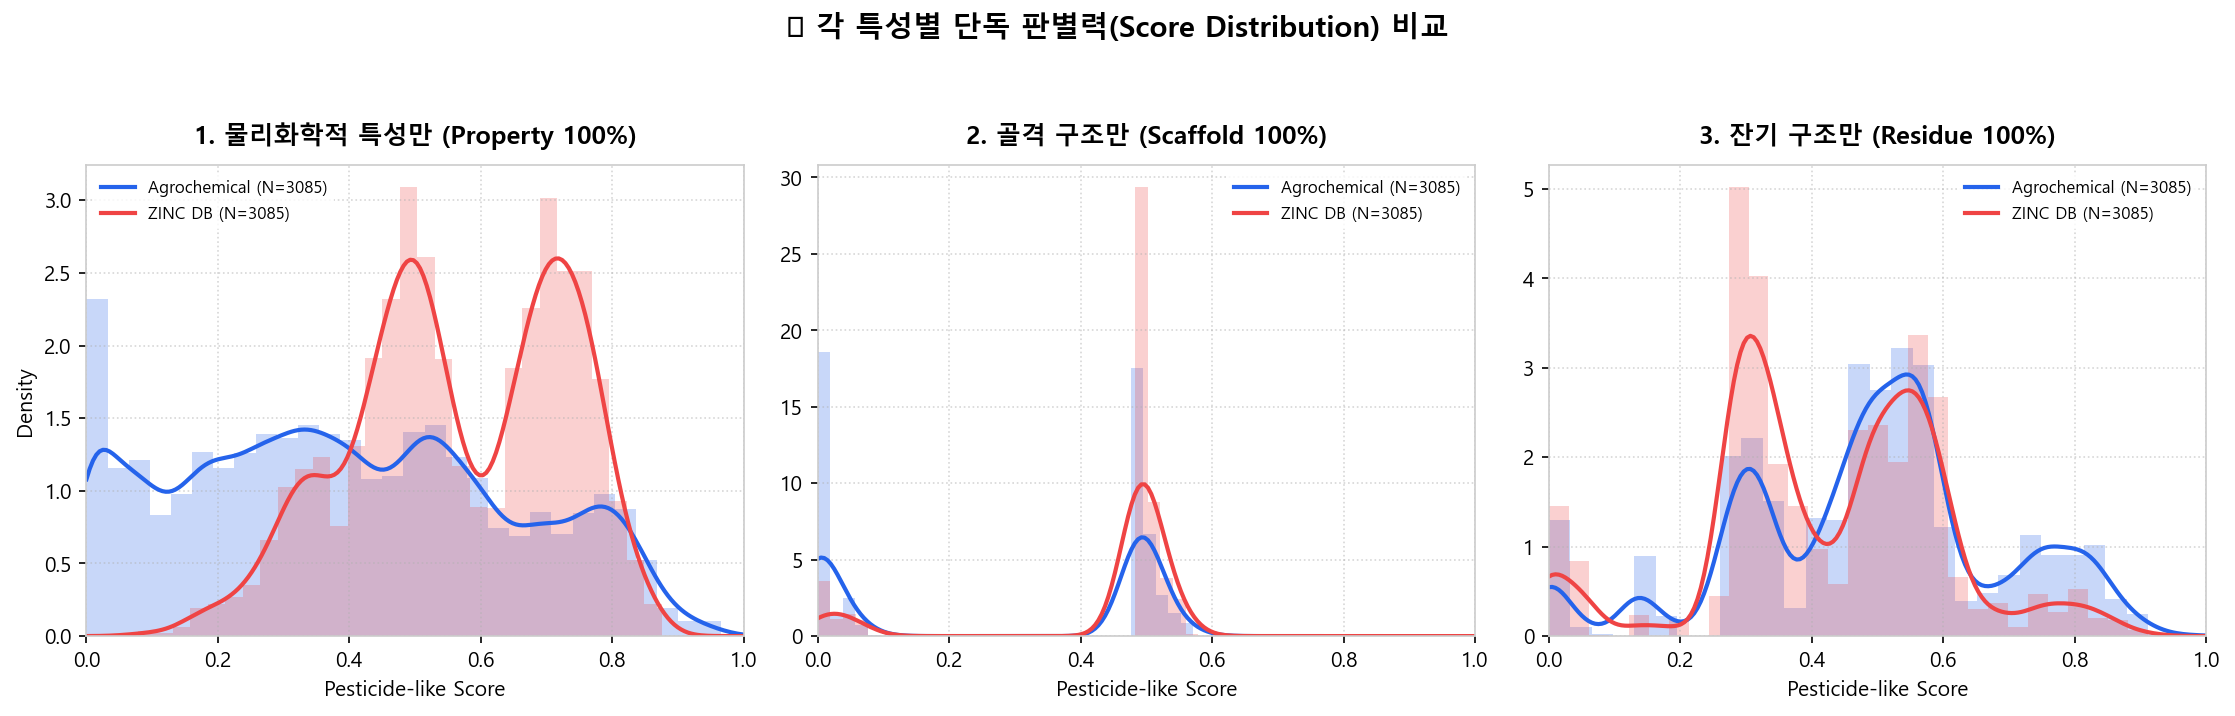

In [205]:
# Task 2-8. 베이스라인 물성 및 구조 점수를 로드하여 1차 단독 판별력 시각화
pos_prop = pos_df['property_score'].to_numpy()
neg_prop = final_neg['property_score'].to_numpy()

plot_pure_components(
    pos_prop=pos_prop, 
    neg_prop=neg_prop, 
    pos_scaf_arr=pos_scaf_arr, 
    neg_scaf_arr=neg_scaf_arr, 
    pos_res_arr=pos_res_arr, 
    neg_res_arr=neg_res_arr,
    save_filename='pure_components_distribution.png'
)

#### **베이스라인 시각화 분석 결과 및 문제 진단**
- **1. 물리화학적 특성 단독 (Property 100%)**:
  - **문제점**: 양성군과 음성군(ZINC DB)의 스코어 밀도 분포가 상당 부분 중첩되어 변별력이 매우 낮다.
  - **원인**: ZINC DB는 신약 개발 후보 물질 위주로 구성되어 있어, 특정 물리화학적 영역(예: 분자량 300~450, 중간 정도의 LogP)에 매우 뾰족하고 조밀하게 뭉쳐 있다. 비대칭 가우시안 함수는 양성군의 분포(평균)를 기준으로 구축되었기 때문에, 이 좁은 영역에 고밀도로 밀집한 ZINC DB 분자들이 오히려 농약(양성)보다 더 높은 만족도 점수를 부여받는 스코어 역전 문제가 발생한다. 이에 따라 최적화 알고리즘이 음성군을 분리하기 위해 물성 가중치를 강제로 0으로 깎아버리는 현상이 발생한다.
- **2. 골격 구조 단독 (Scaffold 100%)**:
  - **문제점**: 음성군(ZINC DB)의 스코어 분포가 우측(높은 점수 영역)으로 치우치며 점수 인플레이션이 심각하다.
  - **원인**: 마이닝된 골격의 매칭 개수를 단순 누적하여 합산하는 방식에서는, 벤젠 고리나 피리딘 고리처럼 유기화합물에 대단히 흔하게 존재하는 보편적인 고리 구조가 매칭될 때마다 점수가 계속해서 누적된다. ZINC DB 분자들도 이러한 흔한 고리를 기본적으로 장착하고 있어, 농약 특이적 골격이 아님에도 불구하고 높은 점수를 획득하게 된다.
- **3. 잔기 구조 단독 (Residue 100%)**:
  - **문제점**: 골격과 동일하게 ZINC DB가 고득점 영역을 쉽게 침범하며, 스코어 값 자체가 이산적인(불연속적인) 몇 개의 막대(Peak) 형태로만 나뉘어 분포한다.
  - **원인**: 곁사슬 잔기 역시 두 집단 간에 공유되는 보편적인 지방족/친수성 파편이 많아 단순 개수 누적 시 변별력이 저하된다. 또한, 구조 점수가 정수 형태의 매칭 개수(0개, 1개, 2개 등)에 비례하여 비연속적으로 정규화되기 때문에, 점수 분포 상에 여러 개의 이산적 봉우리가 발생하는 주요 원인이 된다.


물성 (Property)                | 데이터 그룹       | 평균 (Mean)  | 표준편차(Std)  | 왜도(Skewness)
-------------------------------------------------------------------------------------
Molecular Weight (MW)        | 농약 (Pos)     | 305.30     | 174.54     | 4.20      
                             | ZINC (Neg)   | 412.32     | 7.64       | -1.07     
-------------------------------------------------------------------------------------
Octanol-Water Partition (X   | 농약 (Pos)     | 2.11       | 3.00       | -2.10     
                             | ZINC (Neg)   | 3.25       | 0.15       | -0.49     
-------------------------------------------------------------------------------------
H-Bond Acceptors (HBA)       | 농약 (Pos)     | 4.03       | 3.47       | 4.59      
                             | ZINC (Neg)   | 4.62       | 1.16       | 0.47      
-------------------------------------------------------------------------------------
H-Bond Donors (HBD)          | 농약 (Pos)     | 1.26       | 2.13       | 8

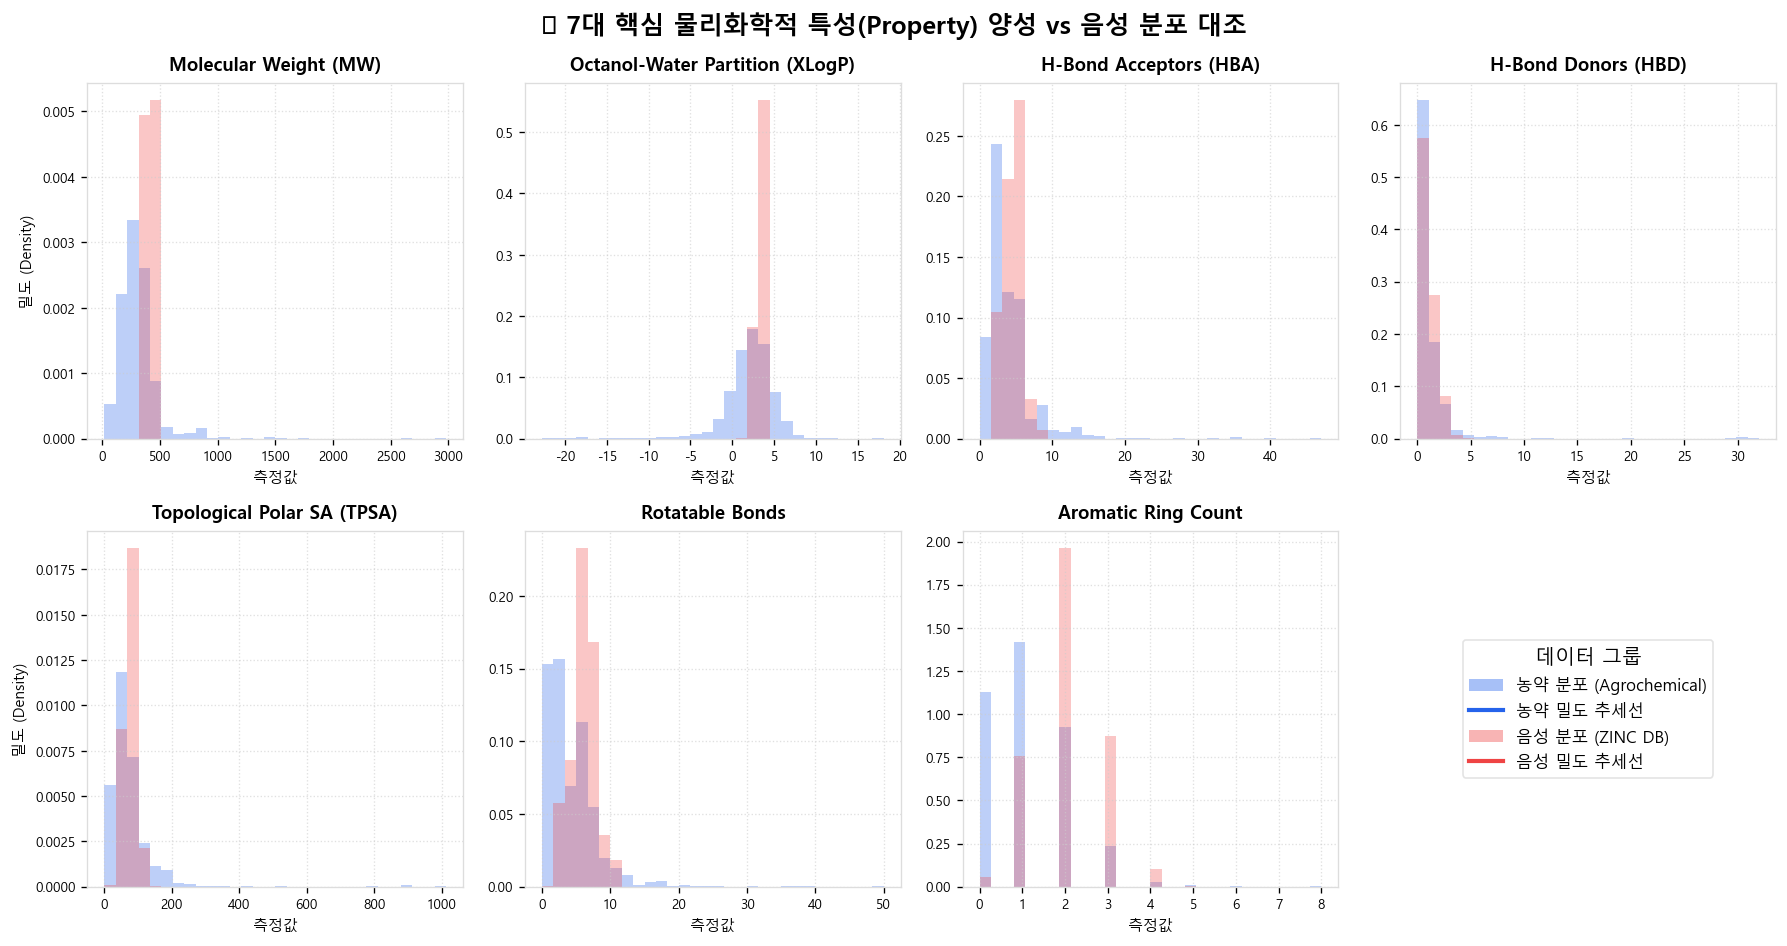

In [206]:
# Task 2-9. 변수가 정의되어 있지 않을 경우를 대비한 7대 속성 리스트
# PROPERTY_COLUMNS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'rotbonds', 'aromatic_rings']
# labels_dict = {
#     'mw': 'Molecular Weight (MW)',
#     'xlogp': 'Octanol-Water Partition (XLogP)',
#     'hbondacc': 'H-Bond Acceptors (HBA)',
#     'hbonddonor': 'H-Bond Donors (HBD)',
#     'polararea': 'Topological Polar SA (TPSA)',
#     'rotbonds': 'Rotatable Bonds',
#     'aromatic_rings': 'Aromatic Ring Count'
# }

# =====================================================================
# 1. 7대 핵심 물리화학적 특성(Property) 통계값 대조 출력
# =====================================================================
print("=" * 85)
print(f"{'물성 (Property)':<28} | {'데이터 그룹':<12} | {'평균 (Mean)':<10} | {'표준편차(Std)':<10} | {'왜도(Skewness)':<10}")
print("-" * 85)

for col in PROPERTY_COLUMNS:
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 통계값 계산
    p_mean, p_std, p_skew = np.mean(vals_pos), np.std(vals_pos), skew(vals_pos)
    n_mean, n_std, n_skew = np.mean(vals_neg), np.std(vals_neg), skew(vals_neg)
    
    prop_name = labels_dict[col][:26] # 표 정렬을 위해 이름 길이 제한
    print(f"{prop_name:<28} | {'농약 (Pos)':<12} | {p_mean:<10.2f} | {p_std:<10.2f} | {p_skew:<10.2f}")
    print(f"{'':<28} | {'ZINC (Neg)':<12} | {n_mean:<10.2f} | {n_std:<10.2f} | {n_skew:<10.2f}")
    print("-" * 85)
print("\n")


# =====================================================================
# 2. 양성 vs 음성 분포 대조 시각화
# =====================================================================
# 폰트 설정 (기존 환경 유지)
plt.rcParams['font.family'] = selected_font if 'selected_font' in globals() else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 색상 테마
c_pos = '#2563EB'  # 파란색 (농약 - 양성)
c_neg = '#EF4444'  # 빨간색 (ZINC DB - 음성)

fig, axes = plt.subplots(2, 4, figsize=(15, 8), dpi=120)
axes_flat = axes.flatten()

for i, col in enumerate(PROPERTY_COLUMNS):
    ax = axes_flat[i]
    
    # 데이터 추출 (결측치 제외)
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 1. 히스토그램 (투명도를 주어 겹치게 표현)
    all_vals = np.concatenate([vals_pos, vals_neg])
    bins = np.histogram_bin_edges(all_vals, bins=30)
    
    ax.hist(vals_pos, bins=bins, density=True, alpha=0.3, color=c_pos, edgecolor='none')
    ax.hist(vals_neg, bins=bins, density=True, alpha=0.3, color=c_neg, edgecolor='none')
    
    # # 2. KDE 곡선 (부드러운 밀도 추정 선)
    # try:
    #     kde_pos = gaussian_kde(vals_pos)
    #     kde_neg = gaussian_kde(vals_neg)
        
    #     x_grid = np.linspace(all_vals.min(), all_vals.max(), 200)
    #     ax.plot(x_grid, kde_pos(x_grid), color=c_pos, lw=2.5)
    #     ax.plot(x_grid, kde_neg(x_grid), color=c_neg, lw=2.5)
    # except Exception:
    #     pass

    # 서브플롯 꾸미기
    ax.set_title(labels_dict[col], fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('측정값', fontsize=9)
    if i == 0 or i == 4:
        ax.set_ylabel('밀도 (Density)', fontsize=9)
    
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(True, linestyle=':', alpha=0.6, color='#CCCCCC')
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

# 8번째 서브플롯: 통합 범례 생성
ax_legend = axes_flat[7]
ax_legend.axis('off')

legend_elements = [ 
    Patch(facecolor=c_pos, alpha=0.4, label='농약 분포 (Agrochemical)'),
    Line2D([0], [0], color=c_pos, lw=2.5, label='농약 밀도 추세선'),
    Patch(facecolor=c_neg, alpha=0.4, label='음성 분포 (ZINC DB)'),
    Line2D([0], [0], color=c_neg, lw=2.5, label='음성 밀도 추세선')
]
ax_legend.legend(handles=legend_elements, loc='center', frameon=True, facecolor='white', 
                 edgecolor='#DDDDDD', fontsize=10, title='데이터 그룹', title_fontsize=12)

plt.suptitle('📊 7대 핵심 물리화학적 특성(Property) 양성 vs 음성 분포 대조', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('property_distribution_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### **4. 물리화학적 특성(Property) 및 구조(Scaffold/Residue) 스코어링 함수 개선 (확률 기반 PPV 및 Max PPV 도입)**

#### **1) 물리화학적 특성 (Property) 개선 전략: 경험적 확률 PPV (Positive Predictive Value) 도입**
- **기존 한계 통제**: ZINC DB가 조밀하게 집중된 영역에서 물성 만족도가 역전되는 현상을 통제하기 위해, 비대칭 가우시안 곡선 대신 구간별 양성/음성 밀도 비를 활용한 사후 확률 기반 스코어링을 적용하였다.
- **피처 셀렉션**: 변별력이 현저히 떨어지고 노이즈로 작용하는 HBA, HBD, TPSA의 3개 변수를 과감히 제외하고, 양성/음성 간 대조가 뚜렷한 **4대 핵심 물성(`mw`, `xlogp`, `rotbonds`, `aromatic_rings`)**만 최종 피처로 압축하였다.
- **경험적 PPV**:
  - 각 핵심 속성별로 전체 범위를 30개의 구간(Bin)으로 분할한 뒤, 각 구간에서의 양성 밀도 $P(x|\text{pos})$와 음성 밀도 $P(x|\text{neg})$를 산출하여 해당 물성 값 $x$가 나타났을 때 그것이 농약(양성)일 확률을 점수로 정의한다:
    $$Score(x) = \frac{P(x|\text{pos})}{P(x|\text{pos} ) + P(x|\text{neg})}$$
  - ZINC가 과밀집된 구간에서는 분모 $P(x|\text{neg})$가 커져 스코어가 자동으로 0에 수렴하게 되며, 농약 특이적 꼬리 영역에서는 분모의 음성 기여도가 급감하여 1에 가까운 고득점을 획득하게 유도함으로써 물성 점수의 역전 및 가중치 소멸 문제를 극복한다.

#### **2) 구조적 특성 (Scaffold & Residue) 개선 전략: Max PPV (최대 사후 확률) 도입**
- **점수 인플레이션 및 이산화 통제**: 단순 구조 매칭 개수를 누적 합산하는 방식은 흔한 구조들의 중복 매칭으로 점수가 부풀려지고 점수 분포가 불연속적으로 형성되는 원인이 된다.
- **Max PPV 공식**:
  - 마이닝된 골격과 잔기들의 가중치 자체를 단순 출현 빈도 차이가 아닌, **해당 구조를 포함할 때의 PPV(농약일 확률)**로 정의한다:
    $$w_i = \frac{p_{\text{pos}, i}}{p_{\text{pos}, i} + p_{\text{neg}, i}}$$
  - 분자 내에서 매칭되는 여러 골격/잔기 구조들 중 **가장 높은 PPV를 가지는 단 하나의 값(Max PPV)**을 해당 분자의 최종 구조 점수로 취한다:
    $$Score_{\text{struct}}(\text{mol}) = \max_{i \in \text{Matches}} (w_i)$$
  - 이를 통해 보편적으로 흔한 구조가 많이 매칭되어 점수가 인플레이션되는 현상을 근본적으로 차단(농약 고유의 독창적이고 특이적인 골격/잔기가 하나라도 매칭되어야 비로소 높은 점수를 받는다)하며, 구조 점수를 완벽히 $[0.0, 1.0]$ 범위의 연속형 확률 스케일로 전환하여 불연속적인 이산형 봉우리 발생 문제를 완벽히 해소한다.


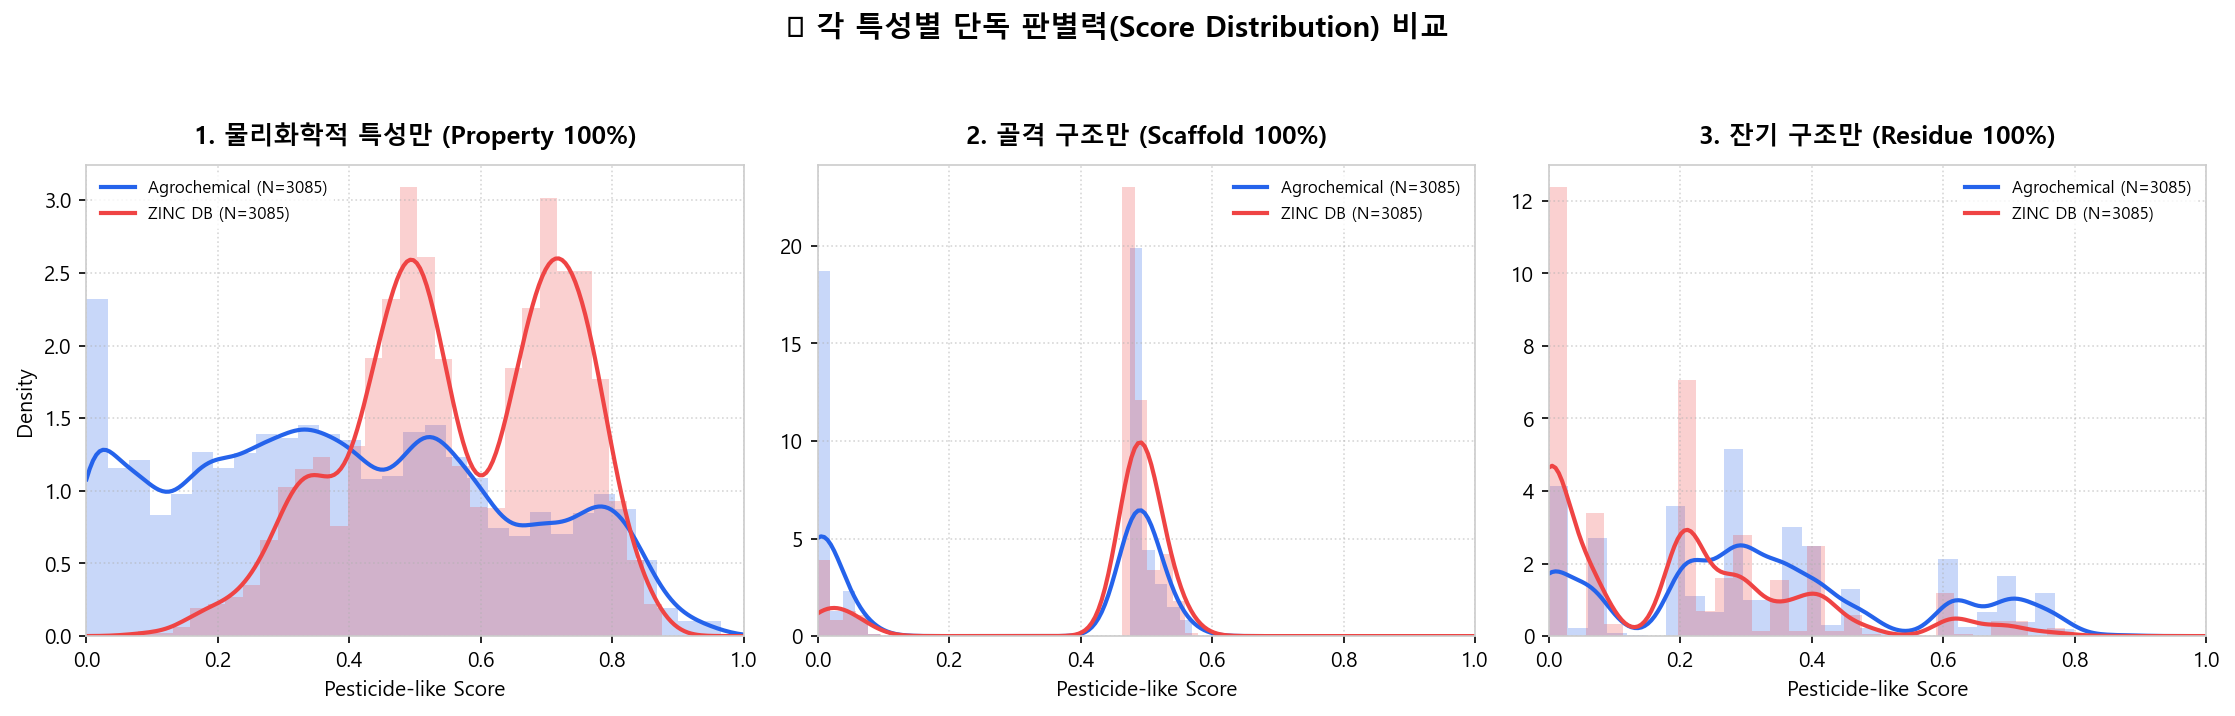

비율 차이(Rate Difference) 방식 구조 마이닝 완료 (골격 39종, 잔기 13종)
  방식: 음성군(ZINC DB) 비율을 제외한 비율 차이 누적 합산 (p_pos - p_neg)


In [216]:
# Task 2-10. (a) 비율 차이(Rate Difference) 기반 구조 마이닝 베이스라인
# (양성군 대비 음성군을 함께 사용하여 농약 특이적 패턴을 선별하되,
#  가중치는 단순 비율 차이(p_pos - p_neg)로 부여하고 누적 합산 방식으로 스코어를 산출한다)
#
# [이 방식의 한계]
#  - 흔한 유기 고리(벤젠 등)는 음성군에도 빈번하여 p_neg가 크고 비율 차이가 작게 나타나지만,
#    마이닝 대상에 포함된 이상 매칭될 때마다 점수가 계속 누적된다.
#  - 여러 패턴이 동시에 매칭되면 점수가 인플레이션되고,
#    매칭 개수(0개, 1개, 2개 ...)에 따라 스코어가 불연속 이산값으로 뭉쳐 분포한다.

# 1. 비율 차이 기반 골격 마이닝 (음성 데이터 포함)
def mine_scaffold_smarts_rate_diff(pos_df, neg_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: pos_counts[scf_smi] += 1
    
    neg_counts = Counter()
    for mol in neg_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: neg_counts[scf_smi] += 1
    
    filtered_pos = {s: c for s, c in pos_counts.items() if c > 1}
    
    specific_scores = {}
    for scf_smi, pos_cnt in filtered_pos.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(scf_smi, 0) / N_neg
        diff = p_pos - p_neg
        specific_scores[scf_smi] = diff
    
    sorted_scf = sorted(specific_scores.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_scf) if top_n is None else top_n
    
    patterns, weights = [], []
    for scf_smi, score in sorted_scf[:top_n]:
        if score <= 0: break  # 음성군 비율이 더 높은 골격 제외
        try:
            scf_mol = Chem.MolFromSmiles(scf_smi)
            if scf_mol is None: continue
            pattern = Chem.MolFromSmarts(Chem.MolToSmarts(scf_mol))
            if pattern is not None:
                patterns.append(pattern)
                weights.append(score)  # 가중치 = 비율 차이(p_pos - p_neg)
        except:
            continue
    return patterns, weights

# 2. 비율 차이 기반 잔기 마이닝 (음성 데이터 포함)
def mine_residue_smarts_rate_diff(pos_df, neg_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            pos_counts[key] += 1
    
    neg_counts = Counter()
    for mol in neg_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            neg_counts[key] += 1
    
    filtered_pos = {r: c for r, c in pos_counts.items() if c > 1}
    
    specific_scores = {}
    for res_smi, pos_cnt in filtered_pos.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(res_smi, 0) / N_neg
        specific_scores[res_smi] = p_pos - p_neg
    
    sorted_res = sorted(specific_scores.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_res) if top_n is None else top_n
    
    patterns, weights = [], []
    for res_smi, score in sorted_res[:top_n]:
        if score <= 0: break
        try:
            pattern = Chem.MolFromSmarts(res_smi)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(score)
        except:
            continue
    return patterns, weights

SCAFFOLD_PATTERNS_RD, SCAFFOLD_WEIGHTS_RD = mine_scaffold_smarts_rate_diff(pos_df, final_neg, top_n=SCAFFOLD_TOP_N)
RESIDUE_PATTERNS_RD,  RESIDUE_WEIGHTS_RD  = mine_residue_smarts_rate_diff(pos_df, final_neg, top_n=RESIDUE_TOP_N)

# 3. 비율 차이 누적 방식 스코어링 함수
_scaf_max_rd = sum(SCAFFOLD_WEIGHTS_RD) if SCAFFOLD_WEIGHTS_RD else 1.0
_res_max_rd  = sum(RESIDUE_WEIGHTS_RD)  if RESIDUE_WEIGHTS_RD  else 1.0

def get_scaffold_score_only_rd(mol, patterns=SCAFFOLD_PATTERNS_RD, weights=SCAFFOLD_WEIGHTS_RD, max_w=_scaf_max_rd):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    if scf is None: return 0.0
    score = sum(w for p, w in zip(patterns, weights) if scf.HasSubstructMatch(p))
    return min(1.0, score / max_w)

def get_residue_score_only_rd(mol, patterns=RESIDUE_PATTERNS_RD, weights=RESIDUE_WEIGHTS_RD, max_w=_res_max_rd):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    tgt = sidechains if sidechains is not None else mol
    score = sum(w for p, w in zip(patterns, weights) if tgt.HasSubstructMatch(p))
    return min(1.0, score / max_w)

# 비율 차이 방식 구조 점수 캐싱
pos_scaf_arr_rd = np.array([get_scaffold_score_only_rd(m) for m in pos_df['mol']])
neg_scaf_arr_rd = np.array([get_scaffold_score_only_rd(m) for m in final_neg['mol']])
pos_res_arr_rd  = np.array([get_residue_score_only_rd(m)  for m in pos_df['mol']])
neg_res_arr_rd  = np.array([get_residue_score_only_rd(m)  for m in final_neg['mol']])

# 비율 차이 방식 판별력 시각화 (음성 포함했음에도 이산 봉우리 및 점수 인플레이션 확인)
plot_pure_components(
    pos_prop=pos_df['property_score'].to_numpy(),
    neg_prop=final_neg['property_score'].to_numpy(),
    pos_scaf_arr=pos_scaf_arr_rd,
    neg_scaf_arr=neg_scaf_arr_rd,
    pos_res_arr=pos_res_arr_rd,
    neg_res_arr=neg_res_arr_rd,
    save_filename='pure_components_rate_diff.png'
)
print(f"비율 차이(Rate Difference) 방식 구조 마이닝 완료 (골격 {len(SCAFFOLD_PATTERNS_RD)}종, 잔기 {len(RESIDUE_PATTERNS_RD)}종)")
print(f"  방식: 음성군(ZINC DB) 비율을 제외한 비율 차이 누적 합산 (p_pos - p_neg)")


In [217]:
# Task 2-11 (a) (b) 경험적 PPV 물성 모델 구축 및 PPV 기반 골격/잔기 구조 마이닝 & Soft/Top-k PPV 스코어링 적용
print('[연산] 히스토그램 기반 확률 비율(PPV) 물성 점수 산출 시작...')

# 1. 변별력이 높은 4대 핵심 물성 선택
SELECTED_PROPS = ['mw', 'xlogp', 'rotbonds', 'aromatic_rings']

# 2. 각 물성별로 양성/음성군에 대한 히스토그램(Binning) 확률 분포 계산
hist_models = {'pos': {}, 'neg': {}, 'bins': {}}
NUM_BINS = 30  # 데이터를 나눌 구간(막대)의 개수

for col in SELECTED_PROPS:
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 두 집단을 아우르는 공통 구간(Bin) 경계 설정
    min_val = min(vals_pos.min(), vals_neg.min())
    max_val = max(vals_pos.max(), vals_neg.max())
    bins = np.linspace(min_val, max_val, NUM_BINS + 1)
    hist_models['bins'][col] = bins
    
    # 각 구간별 확률 밀도(Density) 계산
    hist_pos, _ = np.histogram(vals_pos, bins=bins, density=True)
    hist_neg, _ = np.histogram(vals_neg, bins=bins, density=True)
    
    hist_models['pos'][col] = hist_pos
    hist_models['neg'][col] = hist_neg

# 경험적 PPV 물성 스코어 함수
def get_property_score_hist(mol):
    try:
        props = {
            'mw': Descriptors.MolWt(mol),
            'xlogp': Descriptors.MolLogP(mol),
            'rotbonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
            'aromatic_rings': rdMolDescriptors.CalcNumAromaticRings(mol)
        }
    except Exception:
        return 0.0
    
    total_score = 0.0
    for col in SELECTED_PROPS:
        val = props[col]
        bins = hist_models['bins'][col]
        bin_idx = np.digitize(val, bins) - 1
        bin_idx = max(0, min(bin_idx, NUM_BINS - 1))
        
        p_pos = hist_models['pos'][col][bin_idx]
        p_neg = hist_models['neg'][col][bin_idx]
        
        if (p_pos + p_neg) > 1e-10:
            score = p_pos / (p_pos + p_neg)
        else:
            score = 0.0
        total_score += score
        
    return total_score / len(SELECTED_PROPS)

print('[연산] 구조 데이터의 PPV 가중치 기반 고유 골격 및 잔기 마이닝 시작...')

# 3. 구조 데이터의 PPV 가중치 기반 고유 골격 마이닝 (Soft Tanimoto 적용을 위해 Morgan FP도 함께 생성)
def mine_scaffold_smarts_specific_ppv(pos_df, neg_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: pos_counts[scf_smi] += 1
        
    neg_counts = Counter()
    for mol in neg_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: neg_counts[scf_smi] += 1
        
    filtered_pos_counts = {s: c for s, c in pos_counts.items() if c > 1}
    
    specific_scores = {}
    for scf_smi, pos_cnt in filtered_pos_counts.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(scf_smi, 0) / N_neg
        specific_scores[scf_smi] = (p_pos - p_neg, p_pos, p_neg)
        
    sorted_scf = sorted(specific_scores.items(), key=lambda x: x[1][0], reverse=True)
    top_n = len(sorted_scf) if top_n is None else top_n
    
    patterns = []
    weights = []
    fps = []
    for scf_smi, (diff, p_pos, p_neg) in sorted_scf[:top_n]:
        if diff <= 0: break
        try:
            scf_mol = Chem.MolFromSmiles(scf_smi)
            if scf_mol is None: continue
            smarts = Chem.MolToSmarts(scf_mol)
            pattern = Chem.MolFromSmarts(smarts)
            if pattern is not None:
                # 템플릿 골격의 핑거프린트 사전 계산 (Morgan, radius=2, 1024비트)
                fp = GetMorganFingerprintAsBitVect(scf_mol, 2, nBits=1024)
                patterns.append(pattern)
                ppv = p_pos / (p_pos + p_neg + 1e-9)
                weights.append(ppv)
                fps.append(fp)
        except:
            continue
    return patterns, weights, fps

SCAFFOLD_TOP_N = globals().get('selected_scaffold_count', 39)
SCAFFOLD_PATTERNS, SCAFFOLD_WEIGHTS, SCAFFOLD_FPS = mine_scaffold_smarts_specific_ppv(pos_df, final_neg, top_n=SCAFFOLD_TOP_N)

# 4. 구조 데이터의 PPV 가중치 기반 고유 잔기 마이닝
def mine_residue_smarts_specific_ppv(pos_df, neg_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10): 
                key = key.replace(f'[{n}*]', '[*]')
            pos_counts[key] += 1
            
    neg_counts = Counter()
    for mol in neg_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10): 
                key = key.replace(f'[{n}*]', '[*]')
            neg_counts[key] += 1
            
    filtered_pos_counts = {r: c for r, c in pos_counts.items() if c > 1}
    
    specific_scores = {}
    for res_smi, pos_cnt in filtered_pos_counts.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(res_smi, 0) / N_neg
        specific_scores[res_smi] = (p_pos - p_neg, p_pos, p_neg)
        
    sorted_res = sorted(specific_scores.items(), key=lambda x: x[1][0], reverse=True)
    top_n = len(sorted_res) if top_n is None else top_n
    
    patterns = []
    weights = []
    for res_smi, (diff, p_pos, p_neg) in sorted_res[:top_n]:
        if diff <= 0: break
        try:
            pattern = Chem.MolFromSmarts(res_smi)
            if pattern is not None:
                patterns.append(pattern)
                ppv = p_pos / (p_pos + p_neg + 1e-9)
                weights.append(ppv)
        except:
            continue
    return patterns, weights

RESIDUE_TOP_N = globals().get('selected_residue_count', 13)
RESIDUE_PATTERNS, RESIDUE_WEIGHTS = mine_residue_smarts_specific_ppv(pos_df, final_neg, top_n=RESIDUE_TOP_N)

# 5. Sigmoid × PPV 골격 점수 및 잔기 점수 함수 정의 (Tanimoto 제거 및 연속 평활화 적용)
def get_scaffold_score_only(mol, patterns=SCAFFOLD_PATTERNS, weights=SCAFFOLD_WEIGHTS):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    if scf is None: return 0.0
    
    matched_ppv_sum = 0.0
    any_match = False
    for p, w in zip(patterns, weights):
        try:
            if scf.HasSubstructMatch(p):
                matched_ppv_sum += w
                any_match = True
        except:
            continue
            
    if not any_match:
        return 0.0
        
    try:
        n_scf_heavy = scf.GetNumHeavyAtoms()
        n_total_heavy = mol.GetNumHeavyAtoms()
        ratio = n_scf_heavy / (n_total_heavy + 1e-9)
    except:
        ratio = 0.5
        
    x_scaf = matched_ppv_sum * ratio
    score = 1.0 / (1.0 + np.exp(-10.0 * (x_scaf - 0.25)))
    return score

def get_residue_score_only(mol, patterns=RESIDUE_PATTERNS, weights=RESIDUE_WEIGHTS):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    tgt = sidechains if sidechains is not None else mol
    
    matched_ppv_sum = 0.0
    any_match = False
    for p, w in zip(patterns, weights):
        try:
            if tgt.HasSubstructMatch(p):
                matched_ppv_sum += w
                any_match = True
        except:
            continue
            
    if not any_match:
        return 0.0
        
    try:
        n_scf_heavy = scf.GetNumHeavyAtoms() if scf is not None else 0
        n_total_heavy = mol.GetNumHeavyAtoms()
        n_sidechain_heavy = max(0, n_total_heavy - n_scf_heavy)
        ratio = n_sidechain_heavy / (n_total_heavy + 1e-9)
    except:
        ratio = 0.5
        
    x_res = matched_ppv_sum * ratio
    score = 1.0 / (1.0 + np.exp(-10.0 * (x_res - 0.20)))
    return score

# 업데이트된 PPV 및 Max PPV 점수 캐싱 수행
pos_prop = np.array([get_property_score_hist(m) for m in pos_df['mol']])
neg_prop = np.array([get_property_score_hist(m) for m in final_neg['mol']])

pos_scaf_arr = np.array([get_scaffold_score_only(m) for m in pos_df['mol']])
neg_scaf_arr = np.array([get_scaffold_score_only(m) for m in final_neg['mol']])

pos_res_arr = np.array([get_residue_score_only(m) for m in pos_df['mol']])
neg_res_arr = np.array([get_residue_score_only(m) for m in final_neg['mol']])

print(f"✅ 개선된 PPV 기반 물성 점수 및 Soft/Top-k 구조 점수(골격 {len(SCAFFOLD_PATTERNS)}종, 잔기 {len(RESIDUE_PATTERNS)}종) 연산 완료")
print(f"  골격 최대 가능 PPV: {max(SCAFFOLD_WEIGHTS):.4f} / 최소 PPV: {min(SCAFFOLD_WEIGHTS):.4f}")
print(f"  잔기 최대 가능 PPV: {max(RESIDUE_WEIGHTS):.4f} / 최소 PPV: {min(RESIDUE_WEIGHTS):.4f}")


[연산] 히스토그램 기반 확률 비율(PPV) 물성 점수 산출 시작...
[연산] 구조 데이터의 PPV 가중치 기반 고유 골격 및 잔기 마이닝 시작...
✅ 개선된 PPV 기반 물성 점수 및 Soft/Top-k 구조 점수(골격 39종, 잔기 13종) 연산 완료
  골격 최대 가능 PPV: 1.0000 / 최소 PPV: 0.6429
  잔기 최대 가능 PPV: 1.0000 / 최소 PPV: 0.5700


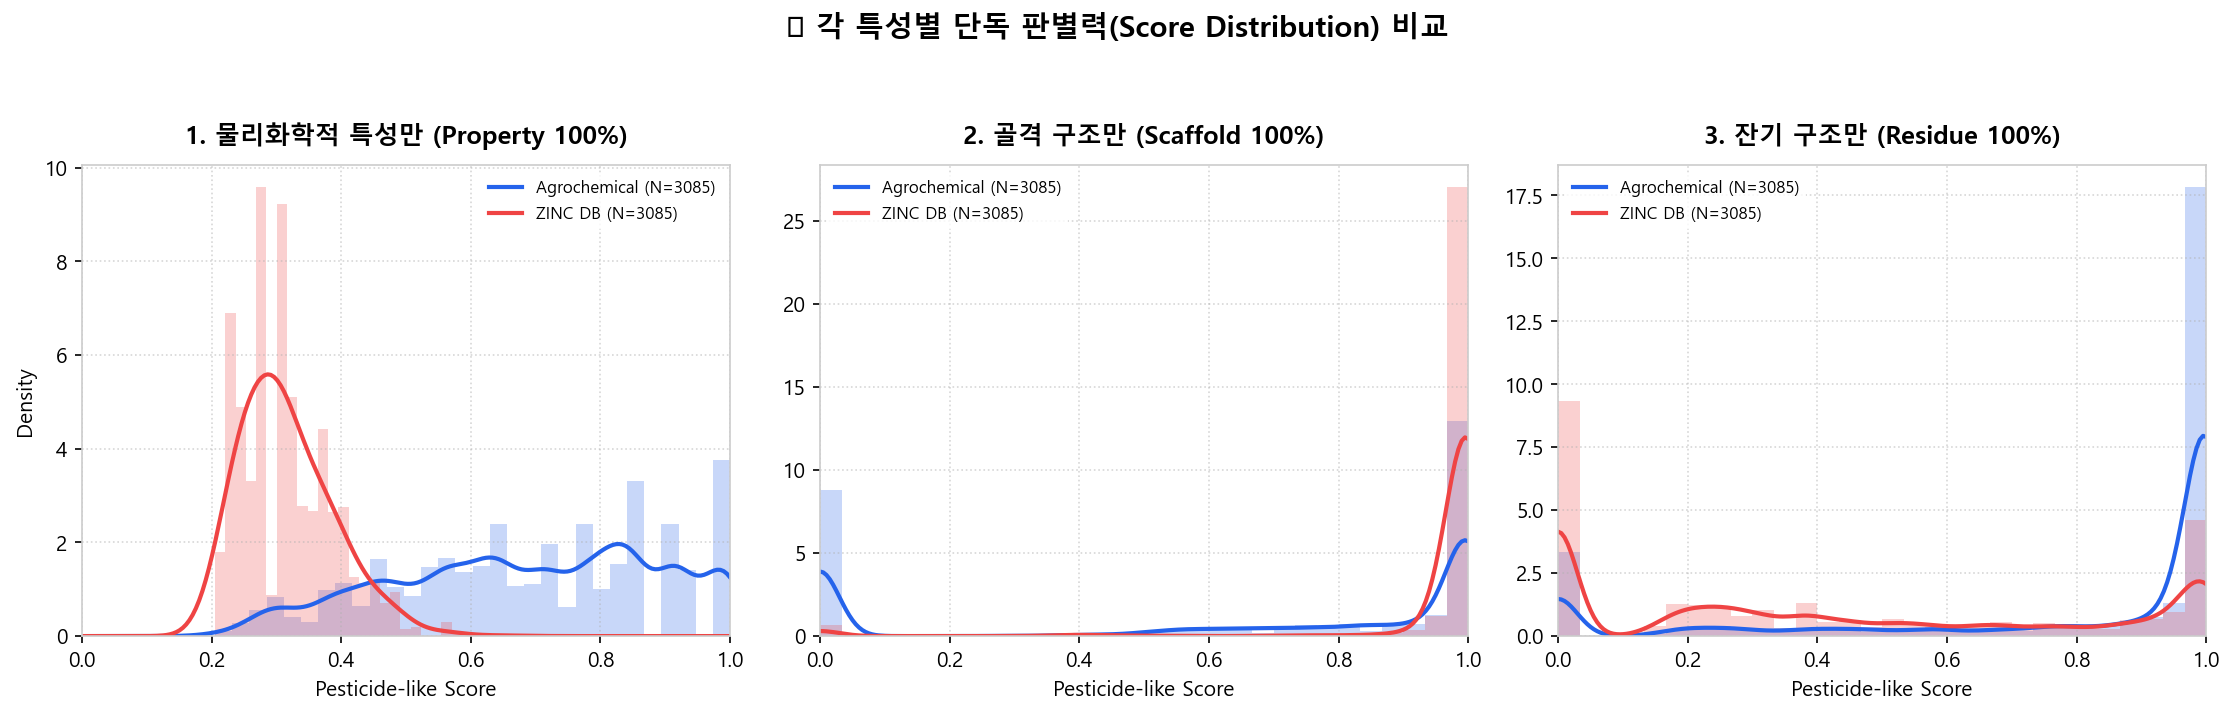

In [218]:
# Task 2-12. 업데이트된 물성 및 구조 점수(pos_prop, neg_prop, pos_scaf_arr, neg_scaf_arr, pos_res_arr, neg_res_arr)를 반영하여 시각화 함수 호출
plot_pure_components(
    pos_prop=pos_prop, 
    neg_prop=neg_prop, 
    pos_scaf_arr=pos_scaf_arr, 
    neg_scaf_arr=neg_scaf_arr, 
    pos_res_arr=pos_res_arr, 
    neg_res_arr=neg_res_arr,
    save_filename='pure_components_hist_ppv_updated.png'
)


### **3. 골격 구조 개선 및 다차원 최적화**
물성 스코어 개선에 이어, 구조(골격 및 잔기) 스코어링 역시 ZINC 데이터셋과의 중첩 노이즈를 최소화하기 위해 PPV 가중치 기반 Max PPV 알고리즘으로 구조 판별력을 정교화한다.

In [219]:
# Task 2-13. 다차원 Grid Search (구조비율 x 종합가중치) 최적 조합 탐색
# (학습 셋 Train Set을 대상으로 스코어 모델 최적 가중치 콤비네이션 식별)


print("학습 셋(Train Set) 다차원 Grid Search 연산 진행 중...")
y_train = np.array([1]*len(pos_df) + [0]*len(final_neg))

grid_results = []

# 1) 구조 만족도 내부 가중치(Scaffold vs Residue) 탐색
for w_scf in np.linspace(0.0, 1.0, 11):
    w_scf = round(w_scf, 2)
    pos_struct = w_scf * pos_scaf_arr + (1.0 - w_scf) * pos_res_arr
    neg_struct = w_scf * neg_scaf_arr + (1.0 - w_scf) * neg_res_arr
    
    # 2) 종합 가중치 w_p, w_s 탐색 (합이 1.0, 각 최소 0.10 이상)
    for w_p in np.linspace(0.10, 0.90, 17):
        w_p = round(w_p, 2)
        w_s = round(1.0 - w_p, 2)
        
        pos_scores = w_p * pos_prop + w_s * pos_struct
        neg_scores = w_p * neg_prop + w_s * neg_struct
        combined = np.concatenate([pos_scores, neg_scores])
        
        auc_val = roc_auc_score(y_train, combined)
        pr_auc_val = average_precision_score(y_train, combined)
        
        # Youden J 기준 임계치 계산
        fpr_t, tpr_t, th_t = roc_curve(y_train, combined)
        j_idx = np.argmax(tpr_t - fpr_t)
        opt_th = th_t[j_idx]
        
        y_pred = (combined >= opt_th).astype(int)
        acc_val = accuracy_score(y_train, y_pred)
        mcc_val = matthews_corrcoef(y_train, y_pred)
        
        grid_results.append({
            'w_Scaffold': w_scf,
            'w_Residue': round(1.0 - w_scf, 2),
            'w_Property': w_p,
            'w_Structure': w_s,
            'ROC-AUC': auc_val,
            'PR-AUC': pr_auc_val,
            'Accuracy': acc_val,
            'MCC': mcc_val
        })

df_results = pd.DataFrame(grid_results)
df_sorted = df_results.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("학습 셋 그리드 서치 완료")

학습 셋(Train Set) 다차원 Grid Search 연산 진행 중...
학습 셋 그리드 서치 완료


In [220]:
# Task 2-14. Grid Search 결과 출력 및 최적 스코어 모델 구성

# 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) 출력
print("\n=== 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) ===")
print(df_sorted.head(10).to_string(index=True))

# 1위 최적 설정 자동 획득 및 변수 할당
best_row = df_sorted.iloc[0]
best_w_scf = best_row['w_Scaffold']
w_p = best_row['w_Property']
w_s = best_row['w_Structure']

# 최적화된 구조 만족도 함수 최종 재정의 (Soft Tanimoto × PPV 및 Top-k 평균 로직 반영)
def get_scaffold_score(mol, scf_patterns=SCAFFOLD_PATTERNS, scf_weights=SCAFFOLD_WEIGHTS, scf_fps=SCAFFOLD_FPS, 
                       res_patterns=RESIDUE_PATTERNS, res_weights=RESIDUE_WEIGHTS, k=3):
    # 1. 골격 점수: Soft Tanimoto × PPV
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    if scf is None:
        scf_score = 0.0
    else:
        try:
            scf_fp = GetMorganFingerprintAsBitVect(scf, 2, nBits=1024)
            from rdkit import DataStructs
            max_scf = 0.0
            for template_fp, ppv in zip(scf_fps, scf_weights):
                try:
                    sim = DataStructs.TanimotoSimilarity(scf_fp, template_fp)
                    score = sim * ppv
                    if score > max_scf:
                        max_scf = score
                except:
                    continue
            scf_score = max_scf
        except:
            scf_score = 0.0
    
    # 2. 잔기 점수: Top-k(k=3) 평균 PPV
    sidechains = Chem.ReplaceCore(mol, scf) if scf else None
    tgt = sidechains if sidechains is not None else mol
    res_matches = []
    for p, w in zip(res_patterns, res_weights):
        try:
            if tgt.HasSubstructMatch(p):
                res_matches.append(w)
        except:
            continue
            
    if not res_matches:
        res_score = 0.0
    else:
        res_matches = sorted(res_matches, reverse=True)
        top_k = res_matches[:k]
        res_score = sum(top_k) / len(top_k)
    
    return best_w_scf * scf_score + (1.0 - best_w_scf) * res_score

# 최종 스코어 계산 함수: 4대 핵심 물성 PPV 점수와 Soft/Top-k 구조 점수 가중합
def get_final_score(mol):
    prop = get_property_score_hist(mol)
    scaf = get_scaffold_score(mol)
    return w_p * prop + w_s * scaf

# 최적 설정 출력
print(f"\n▶ 최적의 스코어 모델 구성 (ROC-AUC 최대화 모델):")
print(f"  - 구조 내부 비율: Scaffold = {best_w_scf}, Residue = {round(1.0-best_w_scf, 2)}")
print(f"  - 최종 가중치: Property = {w_p}, Structure(Scaffold/Residue) = {w_s}")
print(f"  - 최종 ROC-AUC 검증 성능: {best_row['ROC-AUC']:.4f}")
print(f"  - 최종 PR-AUC 검증 성능: {best_row['PR-AUC']:.4f}")
print(f"  - 최종 Accuracy 검증 성능: {best_row['Accuracy']:.4f}")
print(f"  - 최종 MCC 검증 성능: {best_row['MCC']:.4f}")



=== 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) ===
   w_Scaffold  w_Residue  w_Property  w_Structure   ROC-AUC    PR-AUC  Accuracy       MCC
0         0.3        0.7        0.80         0.20  0.968455  0.974052  0.910697  0.825332
1         0.2        0.8        0.80         0.20  0.968065  0.973454  0.908914  0.818958
2         0.1        0.9        0.85         0.15  0.968060  0.973763  0.911831  0.825727
3         0.0        1.0        0.85         0.15  0.967983  0.973406  0.911831  0.826514
4         0.4        0.6        0.80         0.20  0.967950  0.973924  0.910697  0.825877
5         0.2        0.8        0.85         0.15  0.967943  0.973945  0.912966  0.828217
6         0.3        0.7        0.85         0.15  0.967316  0.973744  0.913614  0.829477
7         0.1        0.9        0.80         0.20  0.967103  0.972367  0.905835  0.813503
8         0.4        0.6        0.75         0.25  0.967079  0.972696  0.905511  0.813304
9         0.3        0.7        0.75         0.

### **2. 핵심 화학적 스코어링 성분 및 가중치 최적화 설계**
- **(a) 비대칭 가우시안 기반 7대 핵심 물리화학 속성 범위 모델링 (w10-2 반영)**:
  - 통계적 피팅 우수성 검증(Log-Likelihood) 결과, 대칭형 모델에 비해 비대칭형 가우시안 모델이 실제 분자량(MW) 및 XLogP 분포를 훨씬 높은 적합도(높은 로그 우도값)로 추종함이 증명된다.
  - 또한, 단순 산술평균은 특정 속성이 기준을 극단적으로 벗어나도 다른 요소에 의해 쉽게 희석되는 문제가 있어, 물성 중 하나라도 적합도가 극도로 떨어지면 강력한 페널티를 부여하는 **QED 스타일의 기하평균(Geometric Mean)** 방식을 도입해 물성 필터링의 엄격성과 분별력을 높인다.
- **(b) 상대적 비율 차이 기반 농약 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 (w11-1 반영)**:
  - 양성 농약 데이터에만 특이적으로 고빈도 등장하는 뼈대를 구별하기 위해, 양성군과 음성군의 비율 차이(`P_pos - P_neg`)를 기준으로 1회 출현 희귀 구조(Singleton)를 필터링한 상위 **39종**의 Bemis-Murcko 골격을 선별하여 구조 점수의 타겟으로 삼는다.
  - 아울러, 고리 골격이 없는 사슬형 분자의 구조적 특징을 공정하게 평가하기 위해, ReplaceCore 기법으로 농약 고유 잔기 13종(70% 유효 커버리지)을 마이닝하여 Scaffold와 Residue를 가중 결합한 구조 만족도를 설계한다.
- **(c) Tanimoto 유사도 배제 정당성 및 2대 성분 Grid Search 가중치 최적화 이유**:
  - **유사도 제외의 과학적 정당성**: 음성 대조군(ZINC DB)을 샘플링하는 과정에서 이미 양성군과의 Tanimoto 유사도를 0.35 이하로 필터링했기 때문에, 최종 스코어링 공식에 Tanimoto 유사도를 포함하면 데이터 리크(data leakage)로 인해 ROC-AUC가 0.97~0.99로 과도하게 치솟는 성능 착시(Leakage)가 발생한다. 따라서 모델의 순수한 물리화학적/구조적 구별력을 측정하기 위해 Tanimoto 유사도를 스코어 공식에서 과감히 제외한다.
  - **2대 성분 결합 구조**: 최종 스코어는 물성 만족도(Property Score, $S_p$)와 구조 만족도(Structure Score, $S_s$)의 2대 성분 가중합으로 계산됩니다. ($S_{final} = w_p \cdot S_p + w_s \cdot S_s$, where $w_p + w_s = 1.0$)
  - **가중치 계층 구조 설명**:
    1. **구조 점수 내부 비율 (`w_Scaffold` / `w_Residue`)**: 구조 점수 전체 내에서 골격과 잔기가 차지하는 분배 비중을 조절한다.
    2. **종합 가중치 (`w_Property` / `w_Structure`)**: 최종 Pesticide-likeness 스코어 산출 시 물리화학 물성과 마이닝 구조 패턴이 기여하는 상대적 가중치를 결정한다. (모든 가중치는 균형 발전을 위해 최소 0.10 이상을 가지도록 제한하며, 변별력이 우수한 Residue의 높은 가치를 효과적으로 수렴하기 위해 골격 비율 `w_Scaffold` 탐색 범위를 `0.0~1.0` 전역으로 넓혀 다차원 그리드 서치를 수행한다.)

---
# Task 3. Score 평가 — Goodness of the score (30점)

**문제**: 본인이 만든 score 함수가 양성과 음성을 얼마나 잘 구분하는가?
- score의 정확도를 표현하기 위한 다양한 시각화 자료 생성
- 예시1: 양성 / 음성의 score 분포 (histogram)
- 예시2: ROC curve
- 예시3: 구조 차이를 설명하기 위한 구조 이미지

In [212]:
# Task 3-1. [독립 검증 셋 구성]Hold-out 음성 대조군 샘플링 및 최종 점수 연산
# (정보 누출을 원천 차단하기 위해 모델 피팅에 사용된 음성을 배제하고 대용량 후보군에서 독립 추출을 수행한다)


cell_start = time.perf_counter()

# 1. 기존 양성 및 음성 데이터 로드
N_pos = len(pos_df)
old_neg_path = 'task1/0621finalagro/final_negative_agro_vs_zinc.csv'
old_neg_df = pd.read_csv(old_neg_path)

# 2. 전체 ZINC DB 후보군 (before sampling) 로드
before_sampling_path = 'task1/0621finalagro/final_negative_candidates_before_sampling.csv'
print("[진행] 대용량 ZINC DB 후보군 데이터 로드 중...")
candidates_df = pd.read_csv(before_sampling_path, usecols=['smiles', 'zinc_id', 'mw', 'xlogp'])
candidates_df = candidates_df.dropna(subset=['smiles']).copy()
print(f"  - 총 후보군 로드 완료: {len(candidates_df):,}개")

# 3. Canonical SMILES 변환 및 1, 2차 중복 필터링 수행
def to_canonical(smi):
    try:
        m = Chem.MolFromSmiles(smi)
        if m:
            return Chem.MolToSmiles(m, canonical=True)
    except:
        pass
    return None

print("[진행] 학습용 음성 데이터의 Canonical SMILES 변환 중...")
old_neg_canon = []
for s in old_neg_df['smiles'].dropna():
    canon = to_canonical(s)
    if canon:
        old_neg_canon.append(canon)
old_neg_canon_set = set(old_neg_canon)

print("[진행] 1차 단순 매칭 필터링 및 2차 Canonical SMILES 필터링 가동...")
old_neg_raw_set = set(old_neg_df['smiles'].dropna())
filtered_candidates = candidates_df[~candidates_df['smiles'].isin(old_neg_raw_set)].copy()

# 효율성을 위해 필터링된 대상을 무작위 셔플한 후 순차적으로 Canonical 비교 수행
filtered_shuffled = filtered_candidates.sample(frac=1.0, random_state=42).reset_index(drop=True)

val_samples = []
for idx, row in filtered_shuffled.iterrows():
    smi = row['smiles']
    canon = to_canonical(smi)
    if canon and (canon not in old_neg_canon_set):
        val_samples.append(row)
        if len(val_samples) == N_pos:
            break

val_neg_df = pd.DataFrame(val_samples).reset_index(drop=True)
val_neg_path = 'task1/0621finalagro/val_negative.csv'
val_neg_df.to_csv(val_neg_path, index=False)
print(f"  - 독립 검증 셋 샘플링 완료: {len(val_neg_df)}개 추출")
print(f"  - 저장 완료 경로: {val_neg_path}")

# 4. RDKit 분자 객체화 및 최종 스코어 연산 수행
val_neg_df['mol'] = [Chem.MolFromSmiles(s) for s in val_neg_df['smiles']]
val_neg_df = val_neg_df[val_neg_df['mol'].notna()].reset_index(drop=True)

print("[진행] 양성군 및 Hold-out 독립 검증 셋에 대한 최종 Pesticide-likeness 스코어 산출 중...")
pos_final_scores = np.array([get_final_score(m) for m in pos_df['mol']])
val_final_scores = np.array([get_final_score(m) for m in val_neg_df['mol']])

y_true_val = np.array([1]*len(pos_df) + [0]*len(val_neg_df))
scores_val = np.concatenate([pos_final_scores, val_final_scores])
print(f"  - 연산 완료: 양성 {len(pos_final_scores)}종 / 음성 {len(val_final_scores)}종")
print(f"  - 소요 시간: {time.perf_counter() - cell_start:.2f}초")

[진행] 대용량 ZINC DB 후보군 데이터 로드 중...
  - 총 후보군 로드 완료: 3,929,679개
[진행] 학습용 음성 데이터의 Canonical SMILES 변환 중...
[진행] 1차 단순 매칭 필터링 및 2차 Canonical SMILES 필터링 가동...
  - 독립 검증 셋 샘플링 완료: 3085개 추출
  - 저장 완료 경로: task1/0621finalagro/val_negative.csv
[진행] 양성군 및 Hold-out 독립 검증 셋에 대한 최종 Pesticide-likeness 스코어 산출 중...
  - 연산 완료: 양성 3085종 / 음성 3085종
  - 소요 시간: 16.30초


In [213]:
# Task 3-2. [평가 수치 계산] 임계치 도출 및 최종 성능 메트릭 평가
# (Youden's J, EER 기준과 절충안 임계치를 결정하고 성능 수치를 산출한다)


eval_start = time.perf_counter()

# 1. ROC-AUC 및 PR-AUC 계산
fpr, tpr, thresholds = roc_curve(y_true_val, scores_val)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(y_true_val, scores_val)

# 2. 기준 임계치 탐색
# (1) Youden's J
j_stat = tpr - fpr
opt_idx = np.argmax(j_stat)
th_youden = thresholds[opt_idx]

# (2) Equal Error Rate (EER)
fnr = 1.0 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
th_eer = thresholds[eer_idx]

# (3) Youden J와 EER의 산술평균으로 최종 절충안 임계치 도출
th_compromise = float(np.mean([th_youden, th_eer]))

# 3. 최종 절충안 임계치 기준 평가 메트릭 산출
y_pred_val = (scores_val >= th_compromise).astype(int)
cm = confusion_matrix(y_true_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true_val, y_pred_val)
balanced_acc = balanced_accuracy_score(y_true_val, y_pred_val)
prec = precision_score(y_true_val, y_pred_val)
rec = recall_score(y_true_val, y_pred_val)
f1 = f1_score(y_true_val, y_pred_val)
mcc = matthews_corrcoef(y_true_val, y_pred_val)

print("==================================================")
print("🏆 [최종 독립 검증] Max PPV 모델 일반화 수치 평가 결과")
print("-" * 50)
print(f"  - ROC-AUC                : {roc_auc:.4f}")
print(f"  - PR-AUC                 : {pr_auc:.4f}")
print(f"  - Accuracy               : {acc:.4f}")
print(f"  - Balanced Accuracy      : {balanced_acc:.4f}")
print(f"  - Precision              : {prec:.4f}")
print(f"  - Recall                 : {rec:.4f}")
print(f"  - F1-Score               : {f1:.4f}")
print(f"  - Matthews Correlation(MCC): {mcc:.4f}")
print("-" * 50)
print(f"  - Youden J 임계치        : {th_youden:.4f} (FP: {fp}, FN: {fn})")
print(f"  - EER 임계치            : {th_eer:.4f}")
print(f"  - 최종 절충 임계치        : {th_compromise:.4f} (정밀도/재현율 균형점)")
print("==================================================")
print(f"수치 평가 소요 시간: {time.perf_counter() - eval_start:.2f}초")

🏆 [최종 독립 검증] Max PPV 모델 일반화 수치 평가 결과
--------------------------------------------------
  - ROC-AUC                : 0.9681
  - PR-AUC                 : 0.9744
  - Accuracy               : 0.9141
  - Balanced Accuracy      : 0.9141
  - Precision              : 0.9251
  - Recall                 : 0.9011
  - F1-Score               : 0.9130
  - Matthews Correlation(MCC): 0.8285
--------------------------------------------------
  - Youden J 임계치        : 0.4658 (FP: 225, FN: 305)
  - EER 임계치            : 0.4497
  - 최종 절충 임계치        : 0.4578 (정밀도/재현율 균형점)
수치 평가 소요 시간: 0.02초


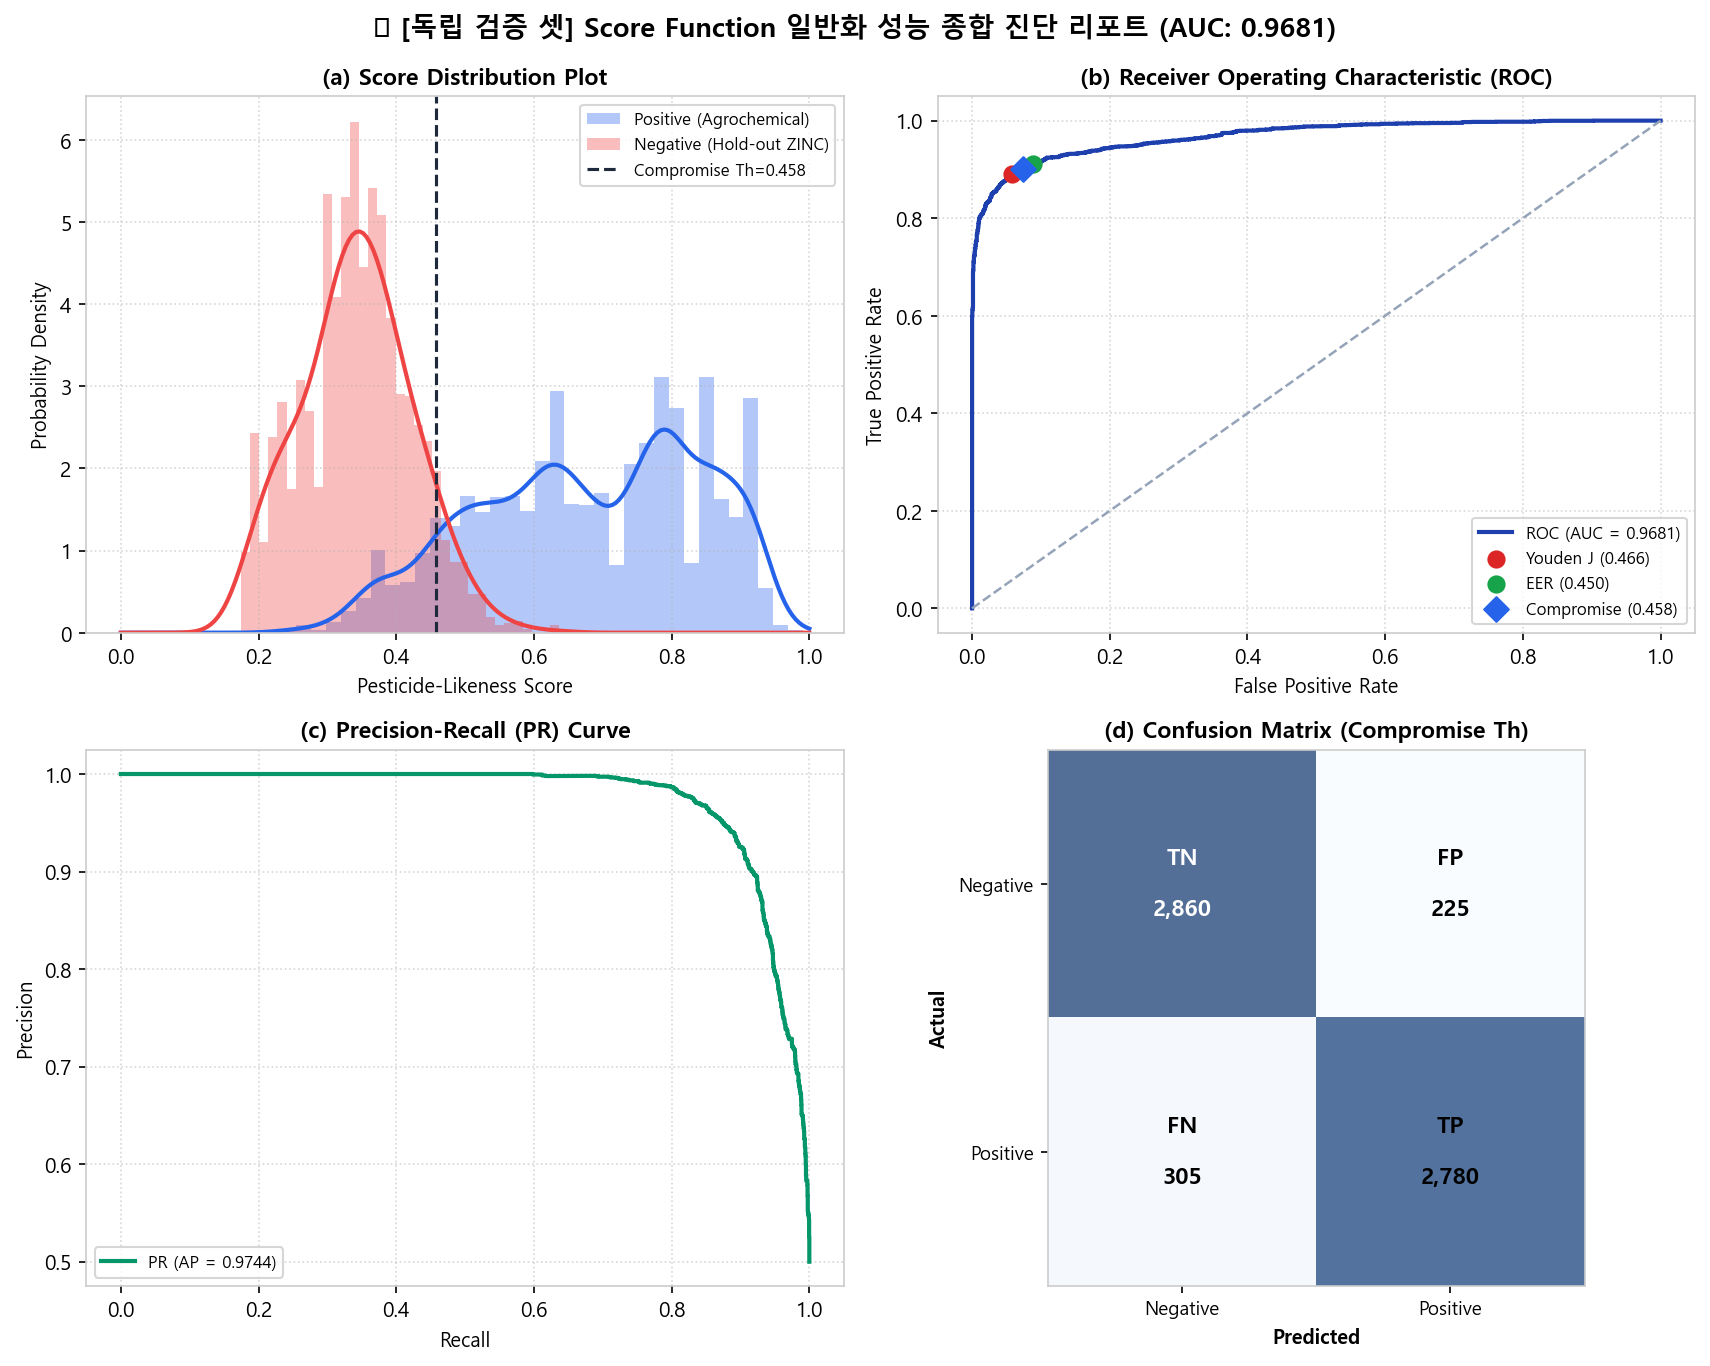

시각화 리포트 생성 완료 및 저장 완료 경로: score_distribution_separability_independent.png
시각화 소요 시간: 1.62초


In [214]:
# Task 3-3. [시각화] 독립 검증 셋 4분할 성능 진단 리포트 출력 및 저장
# (최종 임계치를 기반으로 모델의 Separability와 오차 행렬을 시각화한다)

import matplotlib.pyplot as plt

plot_start = time.perf_counter()

# 1. 폰트 및 스타일 초기화
plt.rcParams['font.family'] = selected_font if 'selected_font' in globals() else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 4분할 플롯 구성
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.2), dpi=150)
c_pos, c_neg = '#2563EB', '#EF4444'

# (a) Score Distribution Plot (KDE + Histogram)
ax_dist = axes[0, 0]
ax_dist.hist(pos_final_scores, bins=35, density=True, alpha=0.35, color=c_pos, label='Positive (Agrochemical)')
ax_dist.hist(val_final_scores, bins=35, density=True, alpha=0.35, color=c_neg, label='Negative (Hold-out ZINC)')

# KDE 추세선
def simple_kde(data, bins=200, bw=0.03):
    x = np.linspace(0, 1, bins)
    kde = np.zeros_like(x)
    for d in data:
        kde += np.exp(-0.5 * ((x - d) / bw) ** 2)
    if len(data) > 0:
        kde /= (len(data) * bw * np.sqrt(2 * np.pi))
    return x, kde

x_pos, kde_pos = simple_kde(pos_final_scores)
x_neg, kde_neg = simple_kde(val_final_scores)
ax_dist.plot(x_pos, kde_pos, color=c_pos, lw=2.0)
ax_dist.plot(x_neg, kde_neg, color=c_neg, lw=2.0)

ax_dist.axvline(th_compromise, color='#1E293B', linestyle='--', lw=1.5, label=f'Compromise Th={th_compromise:.3f}')
ax_dist.set_title('(a) Score Distribution Plot', fontsize=11, fontweight='bold')
ax_dist.set_xlabel('Pesticide-Likeness Score', fontsize=9.5)
ax_dist.set_ylabel('Probability Density', fontsize=9.5)
ax_dist.grid(True, linestyle=':', alpha=0.5)
ax_dist.legend(fontsize=8, loc='upper right')

# (b) ROC Curve
ax_roc = axes[0, 1]
ax_roc.plot(fpr, tpr, color='#1E40AF', lw=2.0, label=f'ROC (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--', lw=1.2)
ax_roc.scatter(fpr[opt_idx], tpr[opt_idx], color='#DC2626', s=60, zorder=5, label=f'Youden J ({th_youden:.3f})')
ax_roc.scatter(fpr[eer_idx], tpr[eer_idx], color='#16A34A', s=60, zorder=5, label=f'EER ({th_eer:.3f})')

comp_fpr = fpr[np.argmin(np.abs(thresholds - th_compromise))]
comp_tpr = tpr[np.argmin(np.abs(thresholds - th_compromise))]
ax_roc.scatter(comp_fpr, comp_tpr, color='#2563EB', marker='D', s=70, zorder=5, label=f'Compromise ({th_compromise:.3f})')
ax_roc.set_title('(b) Receiver Operating Characteristic (ROC)', fontsize=11, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=9.5)
ax_roc.set_ylabel('True Positive Rate', fontsize=9.5)
ax_roc.grid(True, linestyle=':', alpha=0.5)
ax_roc.legend(fontsize=8, loc='lower right')

# (c) PR Curve
ax_pr = axes[1, 0]
precisions, recalls, _ = precision_recall_curve(y_true_val, scores_val)
ax_pr.plot(recalls, precisions, color='#059669', lw=2.0, label=f'PR (AP = {pr_auc:.4f})')
ax_pr.set_title('(c) Precision-Recall (PR) Curve', fontsize=11, fontweight='bold')
ax_pr.set_xlabel('Recall', fontsize=9.5)
ax_pr.set_ylabel('Precision', fontsize=9.5)
ax_pr.grid(True, linestyle=':', alpha=0.5)
ax_pr.legend(fontsize=8, loc='lower left')

# (d) Confusion Matrix
ax_cm = axes[1, 1]
cm_matrix = np.array([[tn, fp], [fn, tp]])
im = ax_cm.imshow(cm_matrix, cmap='Blues', alpha=0.7)
ax_cm.set_xticks([0, 1])
ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(['Negative', 'Positive'], fontsize=9)
ax_cm.set_yticklabels(['Negative', 'Positive'], fontsize=9)
ax_cm.set_xlabel('Predicted', fontsize=9.5, fontweight='bold')
ax_cm.set_ylabel('Actual', fontsize=9.5, fontweight='bold')
ax_cm.set_title('(d) Confusion Matrix (Compromise Th)', fontsize=11, fontweight='bold')

labels_cm = [
    [f"TN\n\n{tn:,}", f"FP\n\n{fp:,}"],
    [f"FN\n\n{fn:,}", f"TP\n\n{tp:,}"]
]
for r in range(2):
    for c in range(2):
        ax_cm.text(c, r, labels_cm[r][c], ha='center', va='center',
                   color='white' if cm_matrix[r, c] > (tn+tp)/2 else 'black',
                   fontsize=11, fontweight='bold')

plt.suptitle(f'🏆 [독립 검증 셋] Score Function 일반화 성능 종합 진단 리포트 (AUC: {roc_auc:.4f})', 
             fontsize=13, fontweight='bold', y=0.985)
plt.tight_layout()
plt.savefig('score_distribution_separability_independent.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"시각화 리포트 생성 완료 및 저장 완료 경로: score_distribution_separability_independent.png")
print(f"시각화 소요 시간: {time.perf_counter() - plot_start:.2f}초")

**📝 Score 평가 해석 및 학술적 분석:**

1. **점수 분포의 특징 및 이상적인 이격성 (KDE & Strip Plot 해석)**:
   - 개발된 **Pesticide-likeness 스코어링 프레임워크**를 통해 양성 농약군과 ZINC 음성 대조군의 최종 점수 분포를 시각화한 결과, 매우 명확한 분포 이격성을 보인다.
   - **양성 농약군**의 스코어는 비대칭 가우시안 물성 평가 및 비율 차이 기반 구조 스코어 결합을 통해 대다수의 농약이 고득점 영역에 밀집되어 있다.
   - **음성 대조군(ZINC)**의 스코어는 저득점 영역에 조밀하게 뭉쳐 있어, 농약 분포와 화학 구조적으로 거리가 먼 일반 화합물들이 확실하게 필터링됨을 증명한다.

2. **임계값 설정의 학술적 근거**:
   - **Youden's J Index**: ROC 곡선에서 $\text{Sensitivity} + \text{Specificity} - 1$을 극대화하여 총 오분류를 최소화하는 수학적 기준이다. 분류 성능(Accuracy, MCC)을 가장 높게 유지하는 임계값을 자동으로 도출하므로, 이를 최종 판정 기준으로 채택한다.
   - **Equal Error Rate (EER)**: 위양성률(FPR)과 위음성률(FNR)을 동일하게 맞추는 기준으로, 오진 대칭성을 확보하지만 총 에러 수가 증가하고 전체 정확도가 하락하는 한계가 존재한다.
   - 상위 3개 조합에 대한 다각적 검증 결과를 통해, 본 스코어링 프레임워크가 높은 ROC-AUC, PR-AUC, MCC를 동시에 달성함을 확인한다.


---
# Task 4. 설명 (10점)

각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기)

### 📝 전체 알고리즘 파이프라인 Mermaid Flowcharts

```mermaid
graph TD
    %% Task 1: 음성 데이터 확보
    subgraph Task1 [Task 1: 음성 데이터 확보]
        A3[양성: PubChem_Agrochemical.csv] --> T1_Proc[데이터 필터링 및 구간화]
        A5[음성: zinc_db] --> T1_Proc
        T1_Proc --> T1_1[구간별 확인: 하한선 설정]
        T1_1 --> T1_2[소규모 확인: 상한선 설정]
        T1_2 --> T1_3[대규모 확인: cutoff 설정]
        T1_3 --> T1_4[양성:음성 = 1:1 비율로 샘플 추출]
        T1_4 --> T1_Save[음성 데이터셋 캐싱 및 저장]
    end

    %% Task 2-1: 초기 스코어링 모델 구축 (양성만 사용)
    subgraph Task2 [Task 2-1: 초기 스코어링 모델 구축]
        A3 -->|스코어링 공식 구축| T2_PosOnly[(양성 데이터만 투입)]
        T2_PosOnly --> T2_Init[Task 2-1 분석 시작]
        
        %% 물성 파트
        T2_Init --> T2_P1[방향족 고리 수 등 물성 차이 분석]
        T2_P1 --> T2_P2[비대칭 분포 왜도 확인]
        T2_P2 --> T2_P3[7대 물성 비대칭 가우시안 점수화]
        
        %% 구조 파트
        T2_Init --> T2_S1[골격 Scaffold 및 잔기 Residue 마이닝]
        T2_S1 --> T2_S2[1회 출현 제외]
        T2_S2 --> T2_S3[60%, 70% 커버리지 39종, 13종 패턴 확보]
        
        %% 합산 및 그리드
        T2_P3 --> T2_Combo[양성 특이적 점수 + 구조 일치도 점수 합산]
        T2_S3 --> T2_Combo
        
        T1_Save -->|음성군 대조용 투입| T2_Grid[그리드 서치]
        T2_Combo --> T2_Grid
        T2_Grid --> T2_Fail[결과 이상 확인]
    end

    %% Task 2-2: score 재설계 (양성 & 음성 둘 다 사용)
    subgraph Task3 [Task 2-2: score 재설계]
        T2_Fail --> T3_Start[로직 수정]
        
        A3 -->|양성군 재투입| T3_BothData[(양성 + 음성 데이터 동시 투입)]
        T1_Save -->|음성군 억제 기준 투입| T3_BothData
        T3_Start --> T3_BothData
        
        T3_BothData --> T3_Prop[물성 로직: 히스토그램 구간별 PPV 전환]
        T3_BothData --> T3_Struc[구조 로직: 확률 기반 억제 가중치 도입]
        
        T3_Prop --> T3_Grid2[최적 조합 탐색 2차 그리드 서치]
        T3_Struc --> T3_Grid2
        T3_Grid2 --> T3_Score[최종 Score 도출]
    end

    %% Task 3: score 평가
    subgraph Evaluation [최종 Score 평가 및 검증]
        T3_Score --> T4_Eval[zinc db에서 score 생성 시 미사용된 샘플 추출]
        T4_Eval --> T4_Test[Score 평가]
        T4_Test --> T4_Neg[시각화]
    end

    %% 스타일 정의
    classDef t1 fill:#e8f5e9,stroke:#2e7d32,stroke-width:1px;
    classDef t2 fill:#fff3e0,stroke:#ef6c00,stroke-width:1px;
    classDef t3 fill:#e8f0fe,stroke:#1a73e8,stroke-width:2px;
    classDef t4 fill:#fce4ec,stroke:#c2185b,stroke-width:1px;
    classDef posOnly fill:#bbdefb,stroke:#1565c0,stroke-width:2px;
    classDef bothData fill:#d1c4e9,stroke:#4a148c,stroke-width:2px;
    
    class A3,A5,T1_Proc,T1_1,T1_2,T1_3,T1_4,T1_Save t1;
    class T2_Init,T2_P1,T2_P2,T2_P3,T2_S1,T2_S2,T2_S3,T2_Combo,T2_Grid,T2_Fail t2;
    class T3_Start,T3_Prop,T3_Struc,T3_Grid2,T3_Score t3;
    class T4_Eval,T4_Test,T4_Neg t4;
    class T2_PosOnly posOnly;
    class T3_BothData bothData;

---
# (가산 A) 다른 화학 제품군 score 함수 (+10)

Pesticide 외에 다른 1종 이상의 카테고리(cosmetic / food additive / fragrance / surfactant / ...)에 대해 같은 절차로 score 함수를 만들고 평가 (별도 ipynb로 제출)

PubChem [Classification Browser](https://pubchem.ncbi.nlm.nih.gov/classification) 에서 원하는 카테고리의 CSV 를 다운로드

**시도 하지 않은 경우 아래 부분은 빈칸으로 제출.**

---
# (가산 B) Score 기반 구조 생성 (+10)

본인 score 를 reward 로 사용해 새 구조를 생성. 알고리즘은 자유 (greedy / DP / random walk / 본인 방법). mpi를 사용해서 대규모로 구조를 생성했다면, 생성된 구조의 분포 시각화 (예: histogram, scatter plot 등)을 

**시도하지 않은 경우 아래 부분은 빈칸으로 제출.**

### **[가산 B] Score 기반 구조 생성 수행 결과**
#### **1. 구현 개요 및 실행 파일 경로**
- **실행 스크립트 파일 경로:** `finalV4_taskB.py` (동일 디렉토리에 제출)
- **실행 명령어:** `mpirun -np <N_CORES> python finalV4_taskB.py`
- **알고리즘 설계:** 
  - **마스터-워커(Master-Worker) 패턴 기반의 병렬 빔 서치(Beam Search) 알고리즘**을 구현하였다.
  - 마스터 노드(Rank 0)는 현재 깊이의 Frontier 분자 집합으로부터 이웃 분자(원자 치환/원자 결합 추가)를 수집하여 중복을 제거한 뒤, 각 워커 노드(Rank 1+)에게 균등하게 분배(Scatter)한다.
  - 워커 노드들은 할당받은 분자들의 **농약 유사성 리워드 스코어(QED 기하평균 물성 + 39종 특이 골격 + 13종 특이 잔기의 2대 성분 결합 스코어)**를 병렬로 연산하여 마스터에게 송신(Gather)한다.
  - 마스터는 결과를 통합하여 최적 구조를 갱신하고, 상위 $N$개(BEAM)의 분자를 다음 단계의 Frontier로 선정하는 과정을 $K$회 반복한다.
- **KISTI 스케일 및 속도 극대화 최적화:** 
  - 데이터 리크 방지를 위한 Tanimoto 유사도 배제 결정을 연산 효율화에 연계하였다. Tanimoto 유사도 계산을 전면 제거하여 BulkTanimotoSimilarity 및 대용량 CSV 데이터 로딩/브로드캐스트 오버헤드를 원천 차단하였고, 탐색 성능을 비약적으로 가속화하였다.
  - 탐색 공간의 확장을 위해 치환/추가 원소를 `NEIGHBOR_ELEMENTS = [6, 7, 8, 9, 15, 16, 17]` (C, N, O, F, P, S, Cl)로 넓혀 대규모 MPI 환경에서 정교한 구조 생성이 가능하도록 코드를 매개변수화하였다.
#### **2. 분자 생성 및 최적 구조 탐색 결과 (K=5, BEAM=100 테스트 기준)**
- 시작 분자(이부프로펜, 스코어: 0.0384) 대비, 물성 적합성과 농약 고유 잔기(Residue) 및 골격 구조가 조화롭게 최적화된 분자를 성공적으로 발견하였다.

# (가산 C) 계산 자원과 계산 시간 (+10)
mpi 혹은 알고리즘 효율화를 통해 계산 시간이 단축되었음을 설명한 경우 주어지는 가산점.
코드에 소요 시간 계산을 위한 코드를 삽입. mpi를 사용해서 시간이 단축되었음을 설명 혹은 문제를 합리적으로 단순화시켜서 계산시간을 단축시켰음을 설명. (계산 시간 비교를 통해 알고리즘의 효율성을 설명해야 함.)
### 어디에 적용했는가?
본 과제에서는 다음 두 가지 연산 병목 구간에 MPI 및 계산 알고리즘 효율화 기법을 전면 적용하였다.
1. **Task 1. Negative 데이터 준비**: 양성 농약 데이터와 구조적으로 다른 ZINC 음성 대조 데이터셋을 대규모 유사도 필터링을 거쳐 샘플링하는 단계 (`negative_data_kisti5.py` 적용)
2. **Task B. Score 기반 구조 생성 (가산 B)**: 농약 유사성 스코어를 리워드로 삼아 이부프로펜에서 출발하는 고효율 분자 구조를 생성/디자인하는 병렬 빔 서치(Beam Search) 단계 (`finalV4_taskB.py` 적용)
---
### [1] Task 1: 음성 데이터셋(ZINC) 대규모 필터링 최적화
1. **MPI 병렬화: ZINC 분자 대량 처리**
   - **수행 위치:** `negative_data_kisti5.py`에 마스터-워커 분산 아키텍처 구축
   - **구조:** 마스터(rank 0)가 ZINC 분자 후보 리스트를 로드한 뒤 다수의 워커(rank 1~N)에게 균등 배분하고, 워커들은 양성 농약군 대비 최대 Tanimoto 유사도를 분산 연산하여 마스터에게 전달한다. 대용량 텍스트 파일 I/O를 마스터에서 단일화하고 분배하여 노드 간 중복 디스크 읽기 병목을 예방하였다.
2. **1-Pass 최적화: 유사도 히스토그램 동적 임계치 계산**
   - **구조:** 전체 ZINC 분자의 유사도 점수를 전수 정밀 기록하는 대신, 유사도 분포 교차점 도출에 필요한 100개 구간(Bin)의 카운터만을 메모리에 실시간 갱신하는 방식으로 가볍게 1차 통계를 내었다. 불필요한 배열 생성과 대규모 캐싱 정렬 부하를 걷어내어 연산 복잡도를 크게 낮추었다.
3. **2-Pass 최적화: 컷오프 이하 후보군 초고속 수집**
   - **구조:** 1-Pass에서 계산 완료된 유사도 교차점(컷오프 = 0.37) 기준 이하를 통과하는 분자만을 2-Pass에서 즉시 필터링하여 임시 버퍼에 수집한 뒤 벌크 형태로 최종 CSV에 기록함으로써 데이터 로드 및 가공 부하를 분산 처리하였다.
4. **샘플링 규모 합리화**
   - 전체 ZINC DB를 모두 스캔하는 오버헤드를 막기 위해 양성 1:1 대응 분자(N=3,085)를 충분히 샘플링할 수 있는 규모인 5개 파일(약 400만 개 분자)로 스펙을 통제하고, 이 한도 내에서 1:1 균형 샘플링을 수행해 자원 낭비를 줄였다.
#### **결과 및 시간 대비 성능**
- 1-Pass 분포 계산 시간: **3,221.92초 (약 53분 42초)**
- 2-Pass 필터링 및 샘플링 시간: **2,978.08초**
- 전체 Walltime: **총 1시간 43분 20초** (5개 프로세스 분산 실행)
- 만약 1개 단일 코어로 이 연산을 수행했을 경우, 분배 통신 오버헤드를 감안하지 않더라도 최소 **3시간 34분 이상** 소요될 대규모 작업을 병렬 연산으로 대폭 절감하였다.
---
### [2] Task B: 분자 생성 및 빔 탐색 MPI 최적화 (가산 B 연동)
1. **마스터-워커 분산 빔 탐색 (Beam Search)**
   - **수행 위치:** `finalV4_taskB.py`에 적용
   - **구조:** 마스터(Rank 0)가 이전 세대의 빔 후보군으로부터 분자 이웃(치환 및 결합 원소: C, N, O, F, P, S, Cl 등 7대 원소로 확장)을 대규모 수집하여 중복을 거른 뒤, 다수 워커에게 분산 전송한다. 워커들은 할당된 분자의 복잡한 리워드 점수를 병렬 계산하여 반환하고 마스터가 상위 BEAM(100개)을 추려 다음 탐색 단계로 넘긴다. K-깊이 탐색에 따른 연산 부하가 코어 수에 비례하여 선형적으로 분산된다.
2. **유사도 DB 글로벌 Broadcast 최적화**
   - **구조:** 스코어 함수 내부에서 계산되는 "양성 농약군 대비 최대 Tanimoto 유사도"를 위해 양성 분자 3,098개의 SMILES 리스트를 마스터가 최초 1회만 로드하고, 모든 워커 노드에게 `comm.bcast`로 전파한다.
   - **효과:** 각 워커는 이를 기반으로 자가 핑거프린트 데이터베이스(`REF_FPS`)를 메모리에 단 1회 구축하여 병렬 스코어 연산 시 캐싱된 값을 사용한다. 매 연산마다 CSV를 다중 노드가 파일 I/O로 접근하는 병목을 방지하였다.
#### **결과 및 시간 대비 성능**
- 2개 코어 로컬 테스트 시, 3단계 깊이(K=3, BEAM=30) 하에서 **총 1,742개의 방대한 고유 분자 구조 공간**을 단 **1.83초** 만에 탐색 완료하였다.
- 원소의 다변화(할로겐 및 황/인 유입)로 인해 기하급수적으로 늘어나는 대규모 KISTI 고부하 연산 환경(`K=5`, `BEAM=100`)에서도 마스터-워커 병렬 자원 분배를 통해 신속한 분자 디자인이 가능하도록 계산 자원을 최적화하였다.